# Neural Fitted Q (NFQ)

In reinforcement learning, we build agents that are capable of learning from feedback that is simultaneously **evaluative, delayed, and sampled**. 

**Delayed feedback**: imagine a chess game in which you make a few wrong moves early on, but the consequences only manifest at the end of the game. Delayed feedback makes it tricky to interpret the source of the feedback and rise the **temporal credit assignment problem**: the challenge of determining which state, action, or state-action pair is responsible for a reward. The opposite is **immediate feedback**. In supervised learning decisions don’t have long-term consequences. For example, in a classification problem, classifying an image, whether correctly or not, has no bearing on future performance.

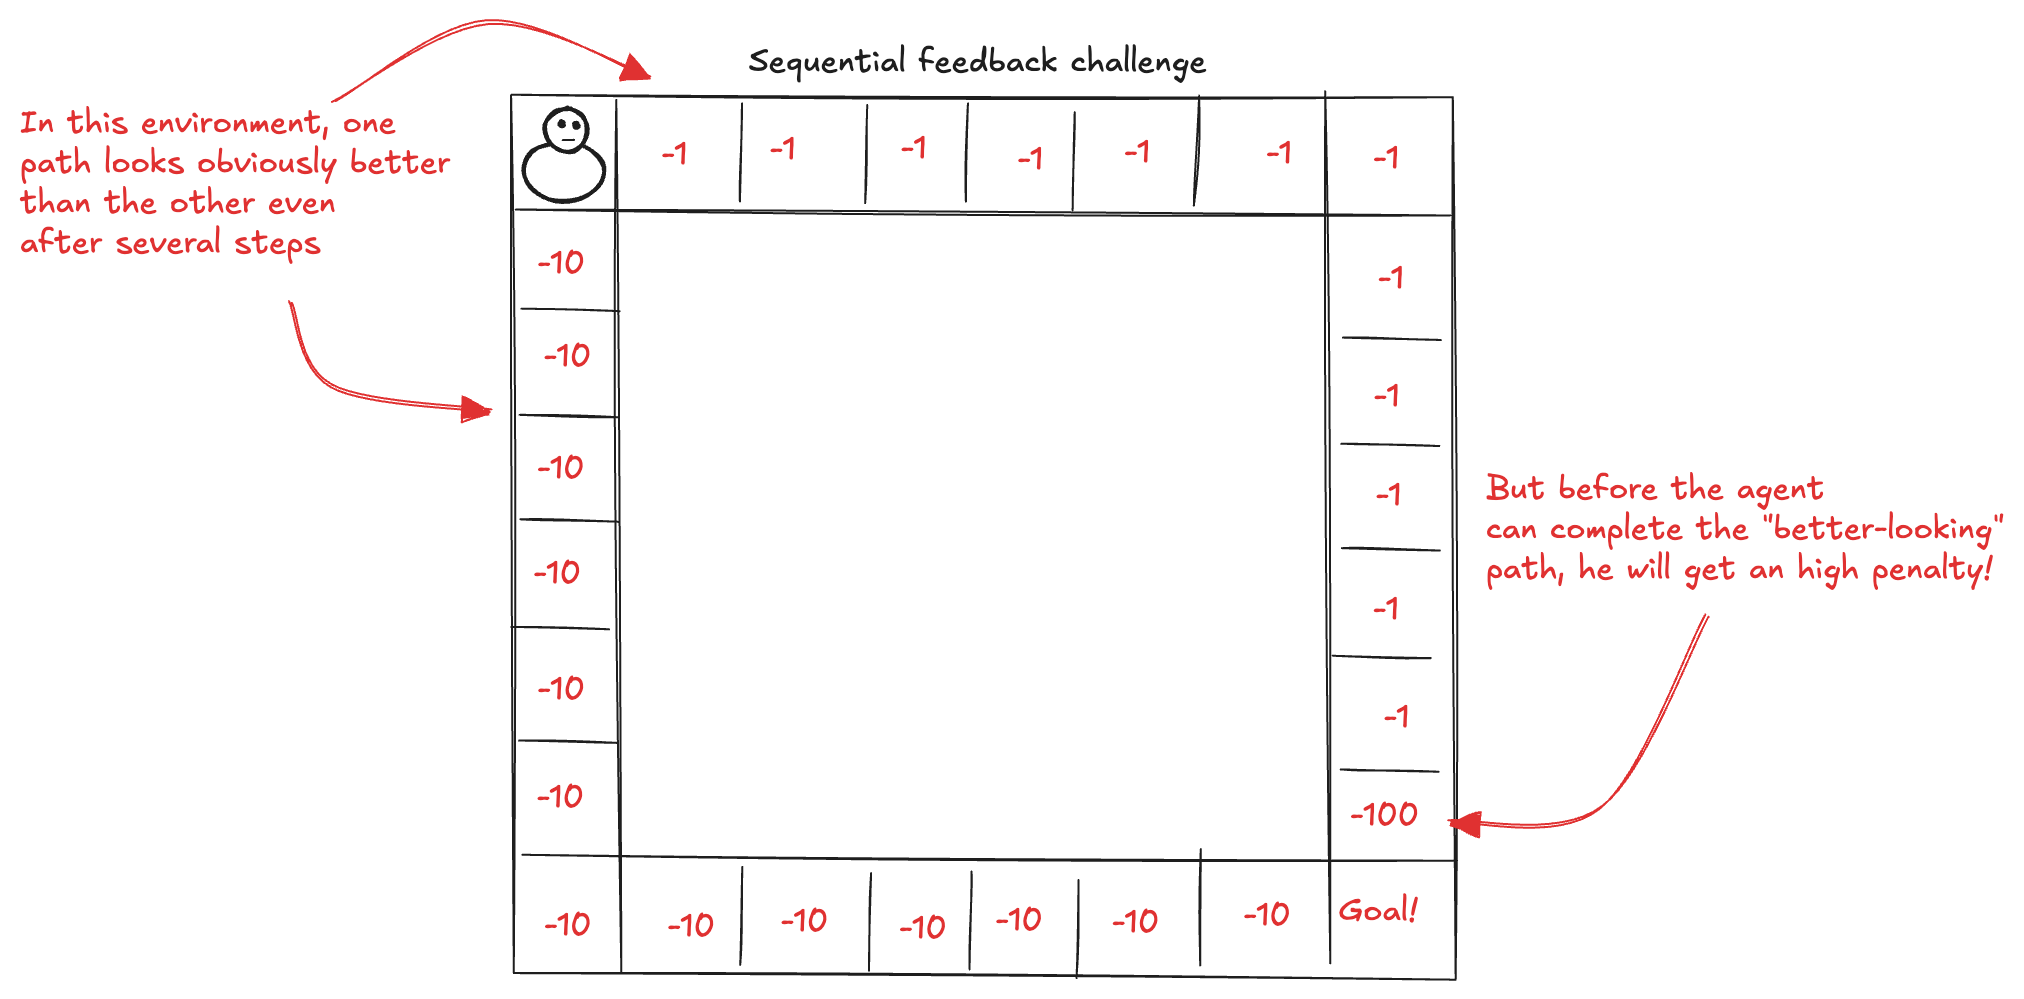

**Evaluative feedback**: the goodness of the feedback is only relative, because the environment is uncertain. The agent doesn’t know the actual dynamics of the environment (no access to the transition and reward functions). As a result, the agent must explore the environment, but the  problem is that by exploring the agent misses capitalizing on its current knowledge. This is the exploration-exploitation trade-off. The opposite is **supervised feedback**. In a classification problem, during learning, the model is given the correct labels for each of the samples provided: there’s no guessing. 

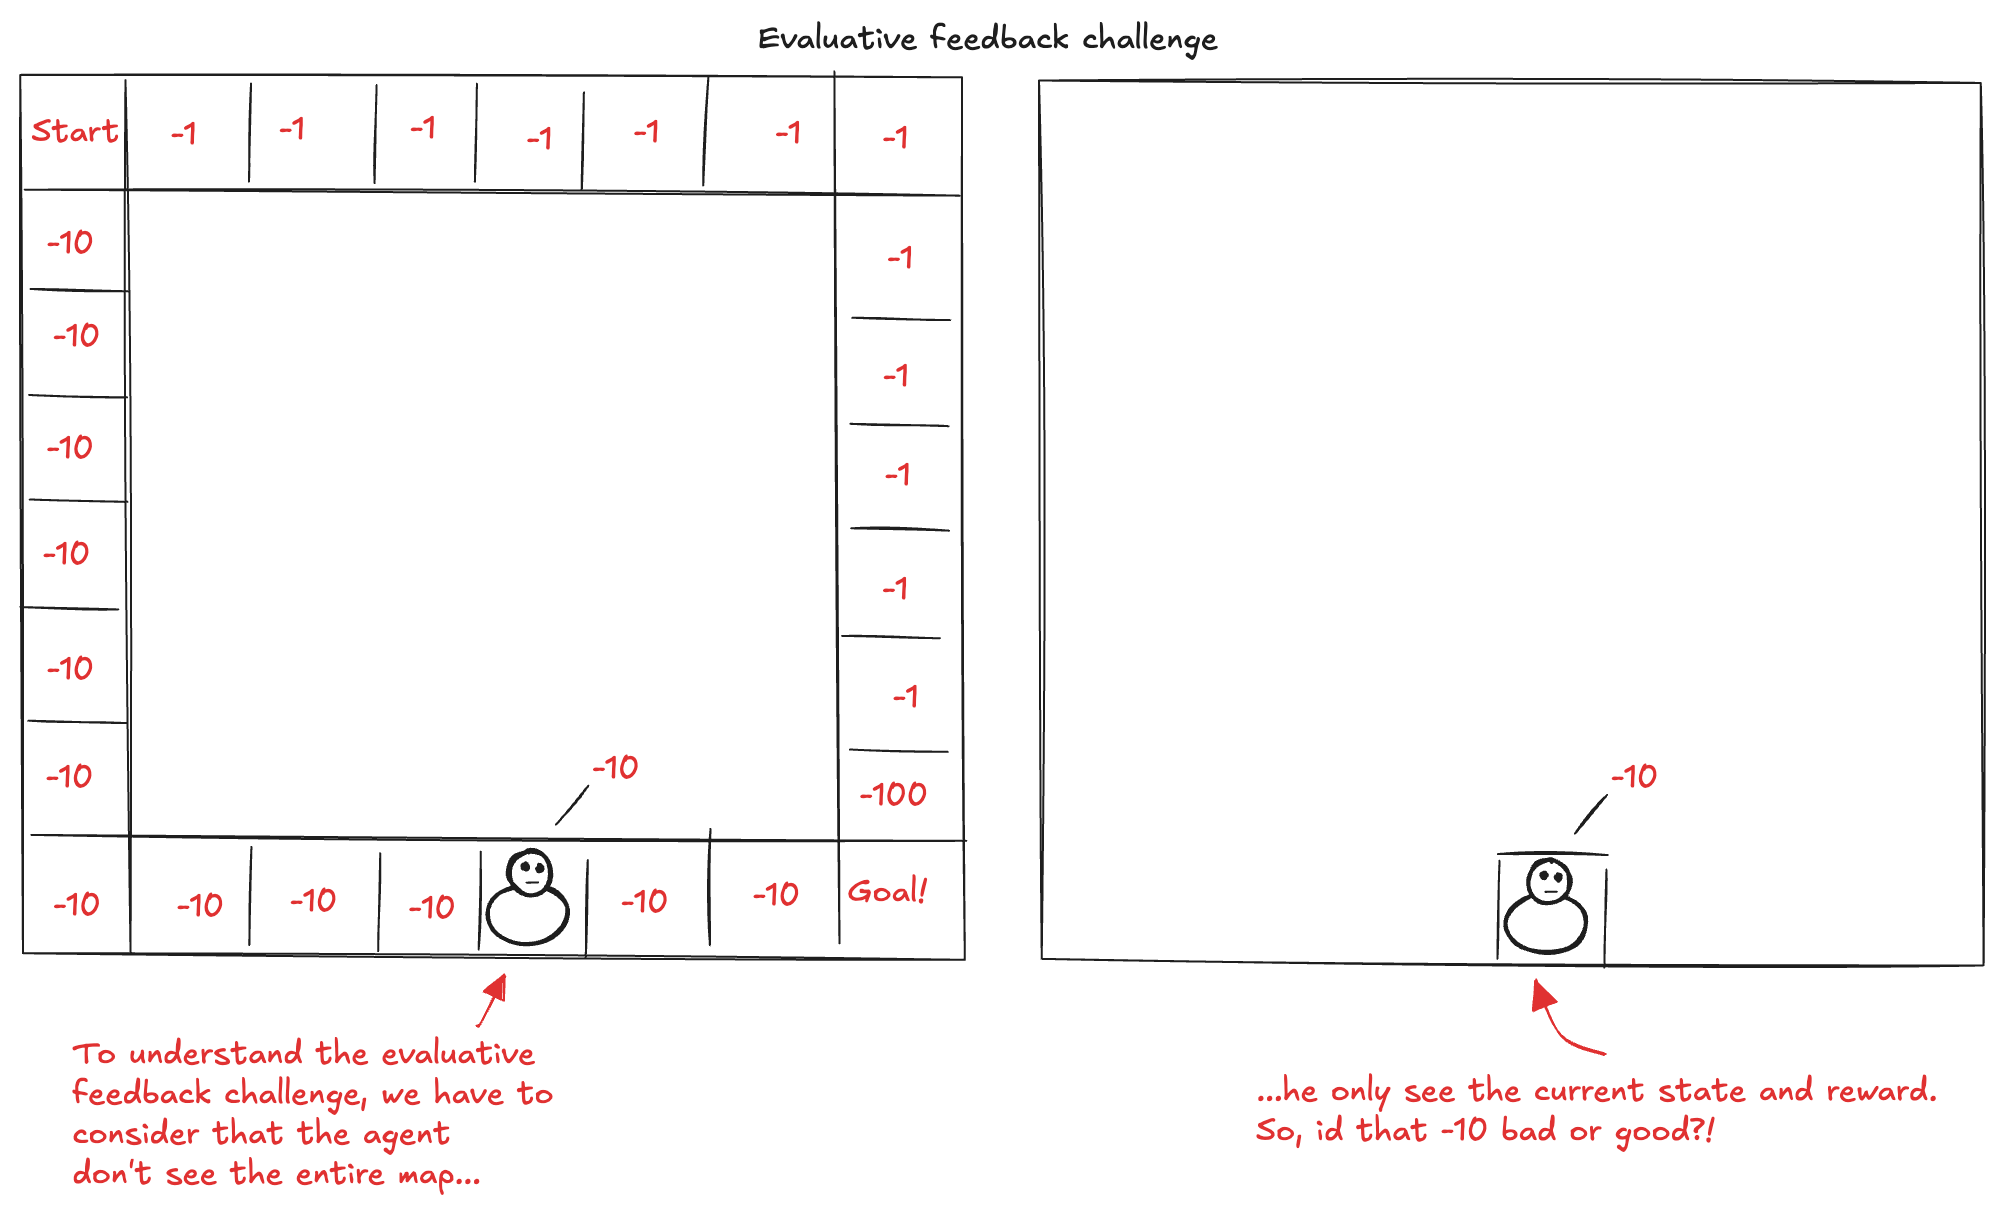

**Sampled feedback**: in real problems, agents are unlikely to sample all possible feedback exhaustively. Agents **need to generalize** using the gathered feedback and come up with intelligent decisions based on that generalization. The opposite is **exhaustive feedback**, where agents have access to all possible samples. Tabular reinforcement learning only needs to sample for long enough to gather all necessary information for optimal performance and they have optimal convergence guarantees. Common assumptions, such as "sampling every state-action pair infinitely often", are reasonable assumptions in small grid worlds with finite state and action spaces, but not in real settings. Consider for example an agent that play a video game:

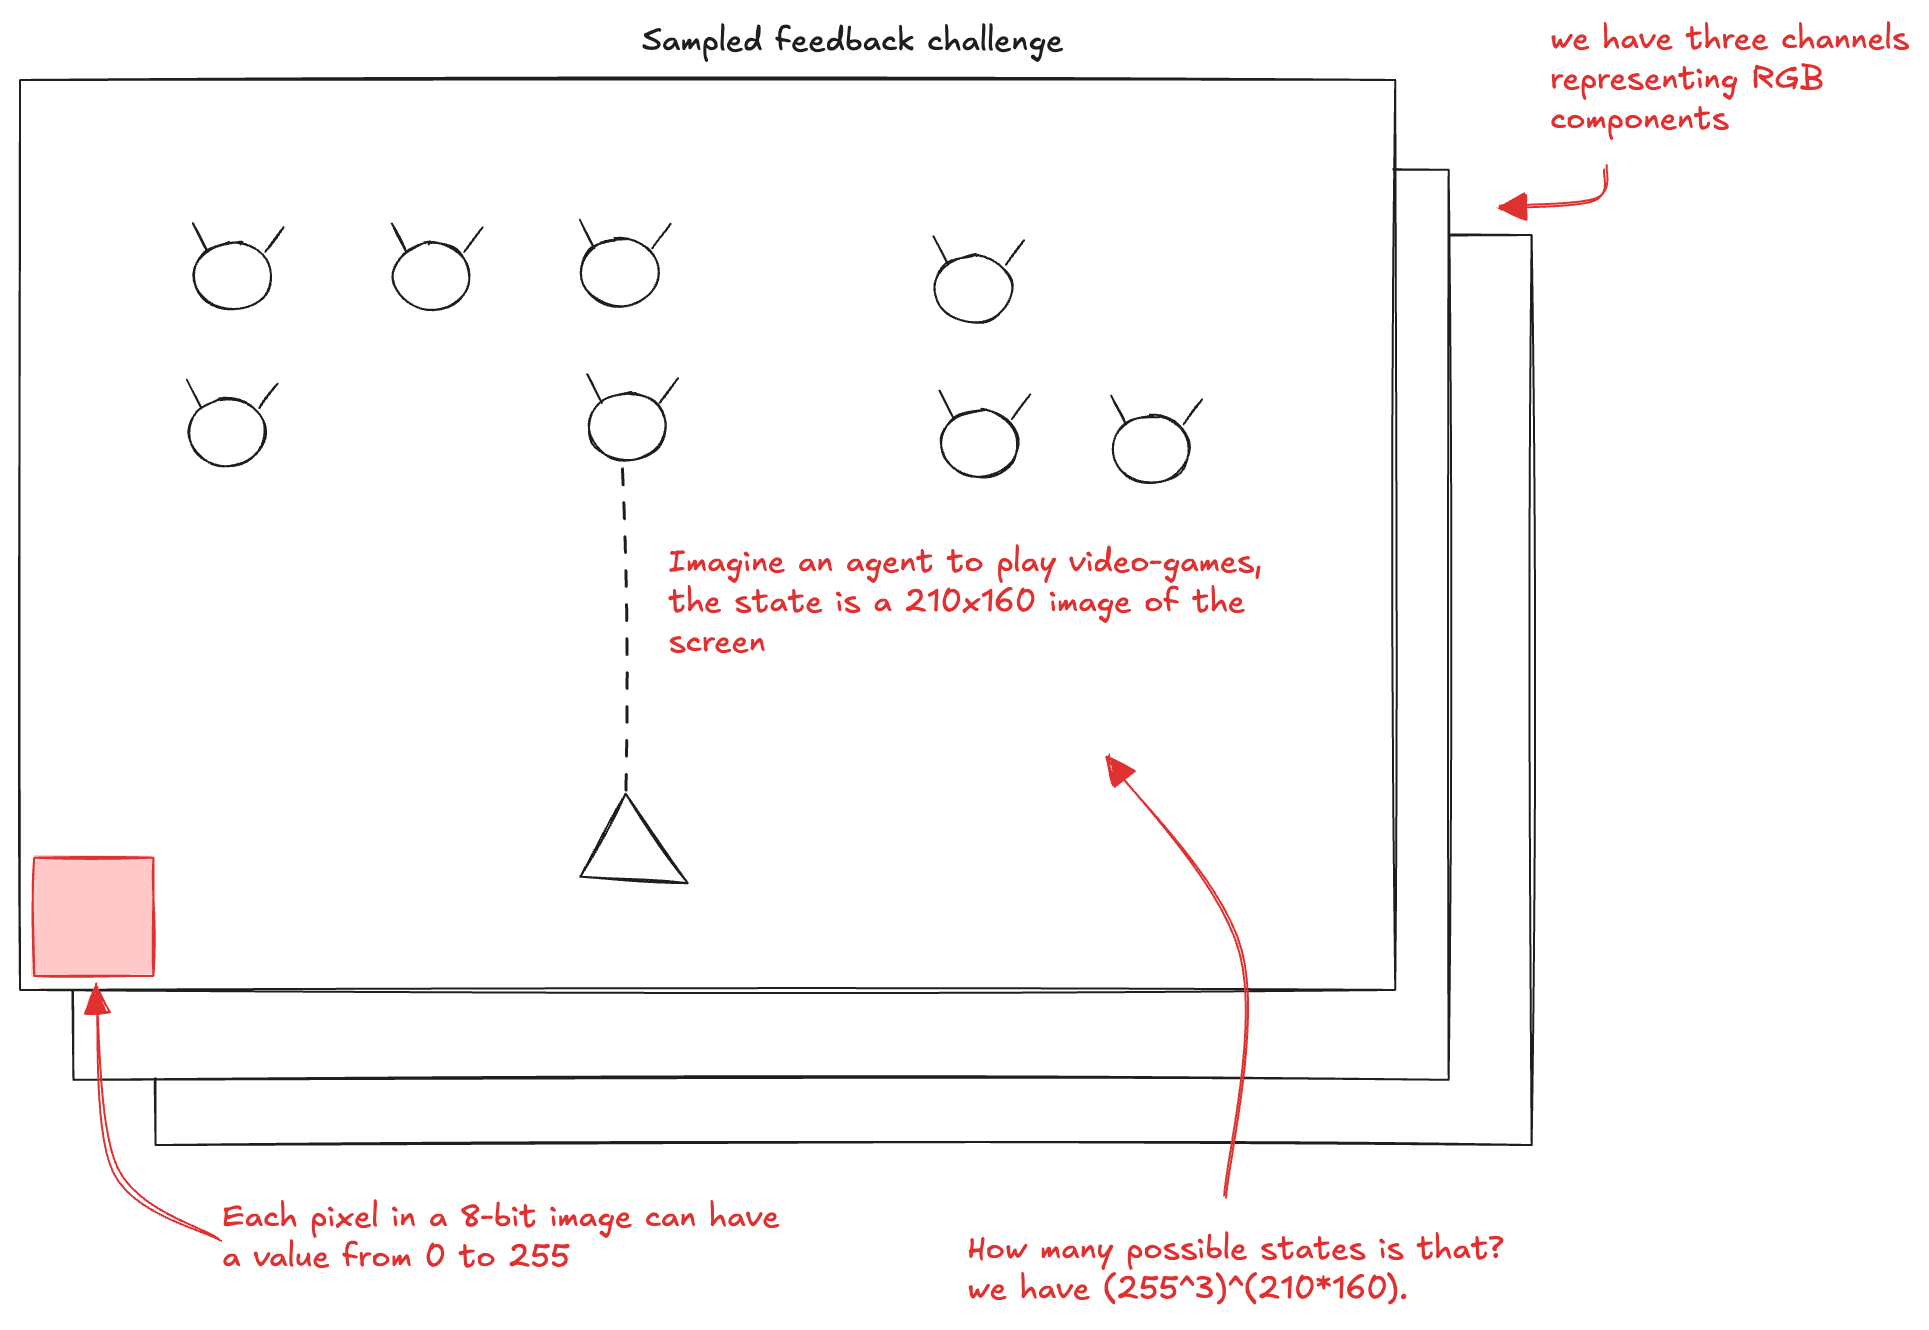

The vast number of states in a video game highlights the limitations of traditional tabular reinforcement learning and necessitates the use of learning methods which can handle high-dimensional state spaces and learn effective policies.

## The need for generalization

The main drawback of the methods that we have seen so far is that they use of a table to represent value functions (for this reason we call them ) **tabular reinforcement learning**) and this is **no practical for complex problems**. For example, Q-learning estimates the values of the optimal value function using a matrix indexed by states and actions:

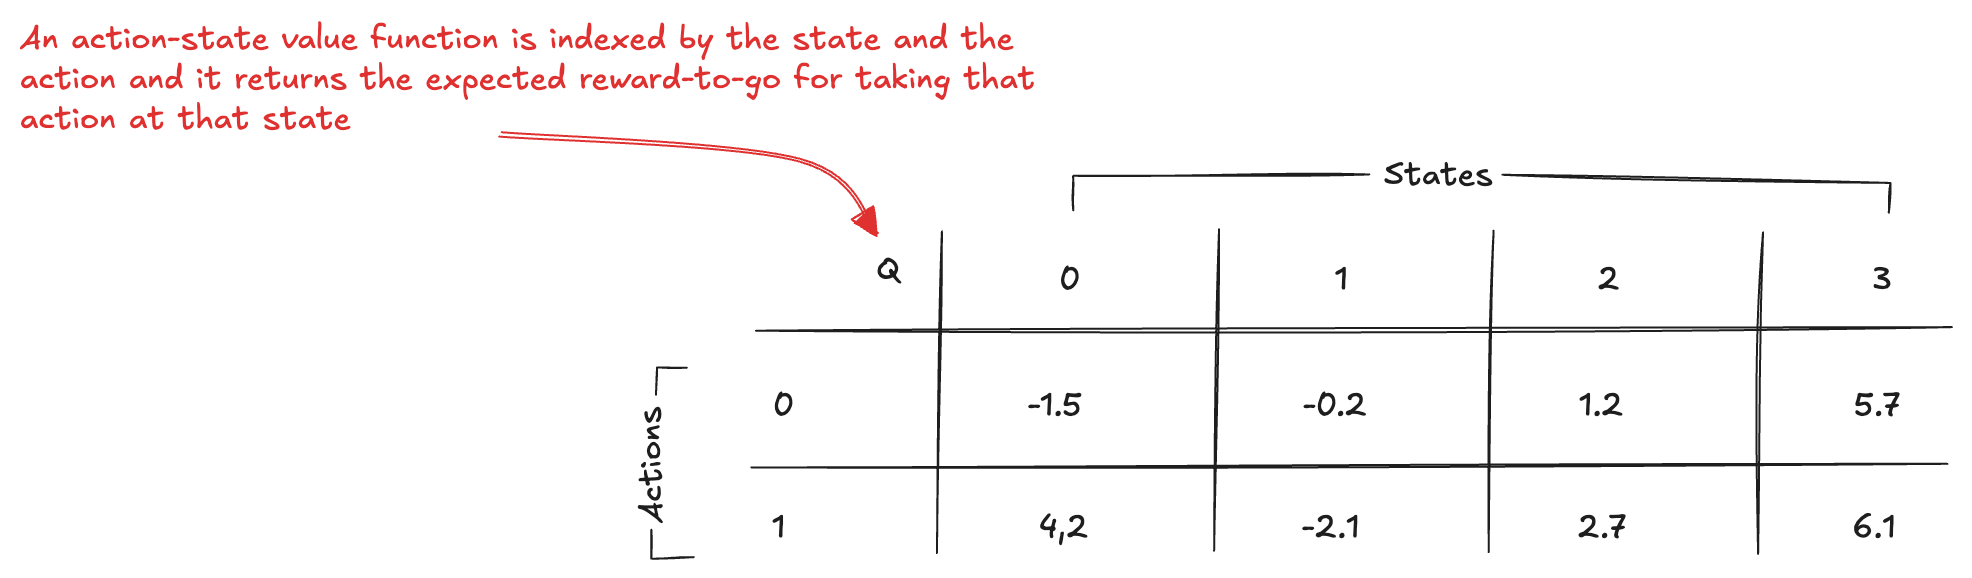

In many of the tasks to which we would like to apply reinforcement learning **the state space is combinatorial and enormous**. Environments can have **high-dimensional state spaces** (the number of variables that comprise a single state is vast) or can additionally have **continuous variables** (a single variable can take on an infinite number of values). How do we make a table that takes all these values into account? We can **discretize the state space**, but they can still take on a large number of values. Tabular solutions are **impractical** for the size of matrices. Moreover, the problem is not just the memory needed for large tables, but **the time needed to fill them accurately**. In many of our target tasks, **almost every state encountered will never have been seen before**. To make sensible decisions it is necessary **to generalize** from previous encounters with different states that are **in some sense similar** to the current one. Tabular solutions are **inefficient** also for the **lack of generalization**, that can discover underlying relationships. But, how can experience with a limited subset of the state space be usefully generalized to produce a good approximation over a much larger subset? Of course, in those conditions, we cannot expect to find optimal policies, our goal should be instead to find **good approximate solutions** using **limited computational resources**.  

**Generalization from examples** has already been extensively studied, and we do not need to invent totally new methods for use in reinforcement learning. To some extent we need only **combine reinforcement learning methods with existing generalization methods**. The kind of generalization we require is often called **function approximation**, because it takes examples from a desired function (e.g., a value function) and attempts to generalize from them to construct an approximation of the entire function. Function approximation is an instance of **supervised learning**. In theory, any of the methods studied in the field of machine learning can be used in the role of function approximator within reinforcement learning algorithms, although in practice some fit more easily into this role than others.

## The Cart-pole environment

In order to illustrate the need for generalization, we will use a classic controlo problem, the **Cart-pole**. The goal is to balance a pole on a cart that can move along a frictionless track. The pole starts upright and the goal is to prevent it from falling over by applying forces to the cart. The state space is low dimensional but **continuous**. Training is fast, yet still somewhat challenging, and function approximation can help. 

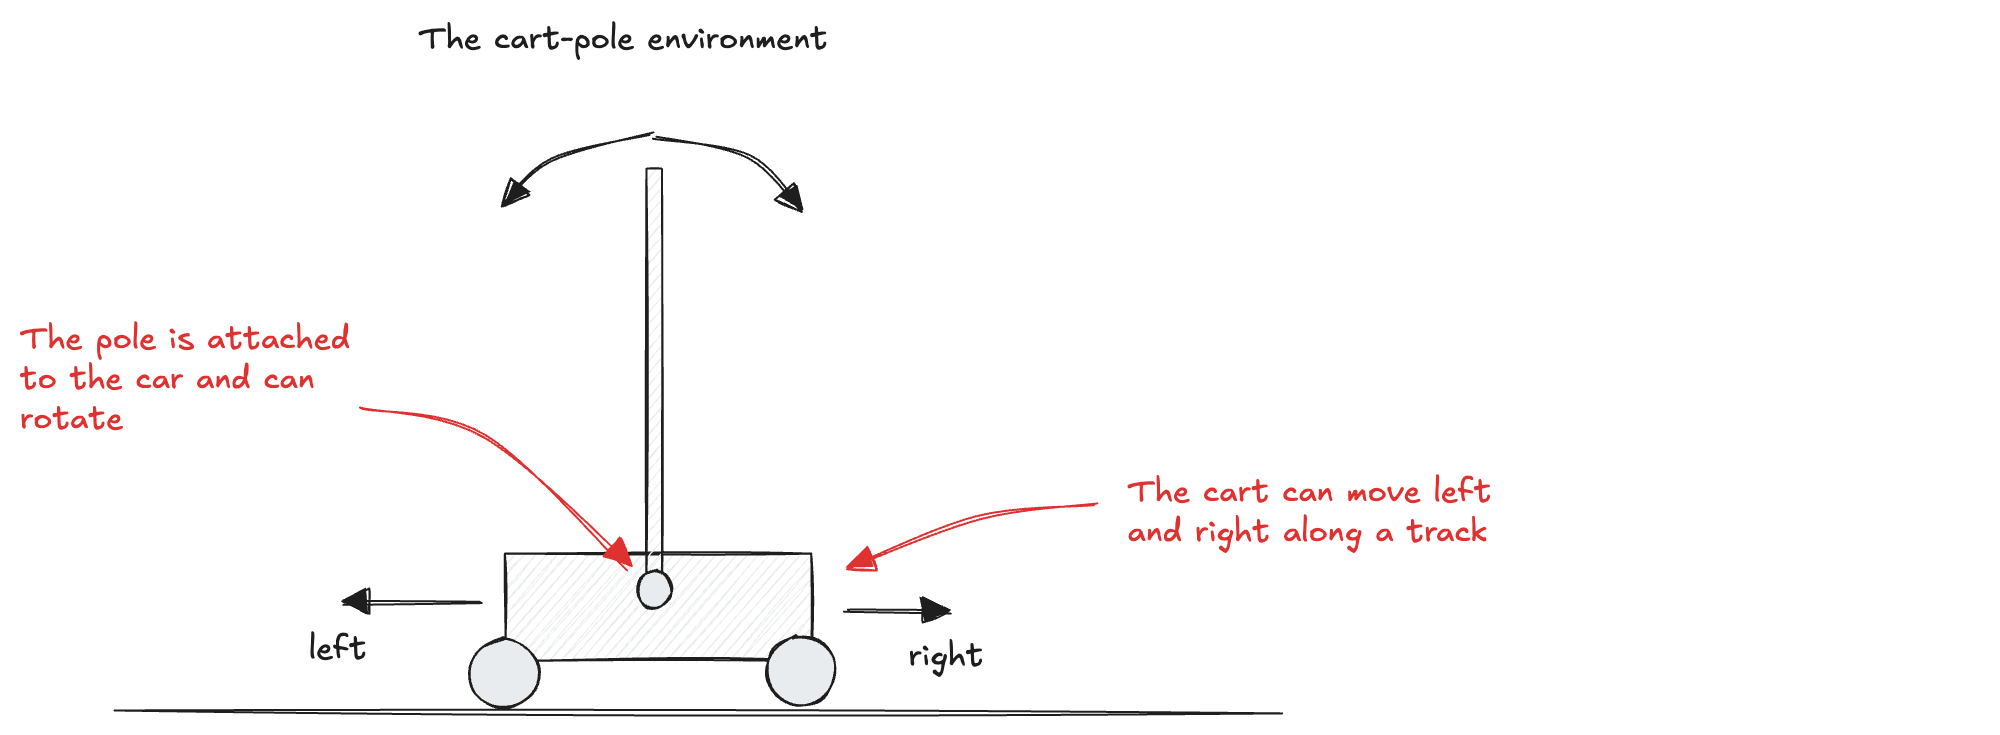

The state space is comprised of four variables: 

- position of the cart on the track (x) with a range from –2.4 to 2.4; 
- velocity of the cart along the track (vc) with a range from –inf to inf; 
- angle of the pole (theta) with a range of –40 degrees to 40 degrees; 
- velocity at the tip (vp) of the pole with a range of –inf to inf.

There are two available actions in every state: 

- action 0 applies a –1 force to the cart (push it left)
- action 1 applies a +1 force to the cart (push it right)

The cart reach a terminal state if: 

- the angle theta is more than 12 degrees away from the vertical position; 
- the center or the cart is more than 2.4 units from the center of the track; 
- the episode count reaches 500 time steps. 

The reward function is +1 for every time step. The environtment is available in the Gymnasium library.

In [1]:
import gymnasium

env = gymnasium.make('CartPole-v1', render_mode="rgb_array");

We can get the state space and the action space sizes of the environment:

In [2]:
state_size = env.observation_space.shape;
action_size = env.action_space.n;

print('State Space: ', state_size);
print('Action Space: ', action_size);

State Space:  (4,)
Action Space:  2


We want to be able to reproduce the results, so we will fix the random seed:

In [3]:
import torch;
import numpy as np;
import random;

# set the seeds for reproducibility of results
seed = 34;

torch.manual_seed(seed);
np.random.seed(seed);
random.seed(seed);

env.reset(seed=seed)
env.action_space.seed(seed)
env.observation_space.seed(seed)

34

As a baseline for comparison, we introduce a **random policy**, which selects actions uniformly at random from the action space; although it has no learning capability, it provides a useful reference point to evaluate how much the learned policy actually improves over uninformed behavior:

In [4]:
def random_pi(state):
    # selects an action uniformly at random
    # from the environment's action space.
    return env.action_space.sample()

To better understand how the agent interacts with the environment, we define a visualization function that displays the policy’s behavior step by step, allowing us to observe in real time how its decisions evolve throughout an episode:

In [5]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_policy(pi, n_episodes=1, max_steps=500):

    # start the episodes    
    for episode in range(n_episodes):

        # reset the environment
        state, _ = env.reset();
        done = False;

        # initialize the step counter
        step = 0;

        # run the episode until done or max_steps
        while not done and step < max_steps:

            # make a step
            action = pi(state);
            state, _, terminated, truncated, _ = env.step(action);
            done = terminated or truncated;
            
            # render the environment
            clear_output(wait=True)
            plt.imshow(env.render())
            plt.axis("off")
            plt.title(f"Episode {episode+1}, Step {step}")
            plt.show()
            plt.close()

            # increment the step counter
            step += 1;   

When applied to the CartPole environment, the random policy performs very poorly. Because its actions are selected uniformly at random, it lacks any notion of balance or control, causing the pole to fall almost immediately. Episodes typically last only a few time steps before termination, resulting in very low total rewards:

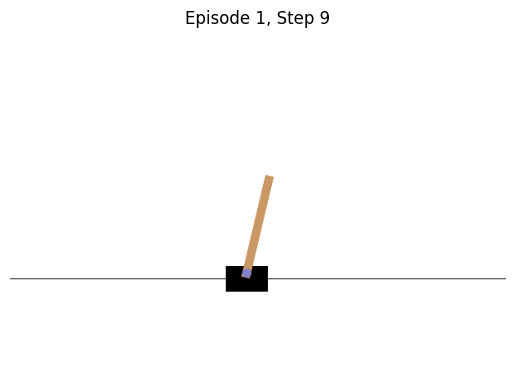

In [6]:
show_policy(random_pi, n_episodes=1, max_steps=500);

To **quantitatively assess** how well a policy performs, we define an evaluation function that runs the agent for a specified number of episodes, accumulates the total reward obtained in each, and returns the average episode reward. This provides a simple but effective measure of overall policy quality, allowing us to compare different strategies under consistent conditions:

In [7]:
def evaluate(pi, episodes=1):

    # collect total rewards per episode
    rewards = [];

    # loop over episodes
    for episode in range(episodes):

        # reset the environment
        state, _ = env.reset();
        done = False;
        total_reward = 0.0;

        # run an episode
        while not done:
            action = pi(state);
            state, reward, terminal, truncated, _ = env.step(action)
            total_reward += reward;
            done = terminal or truncated;

        # store the total reward    
        rewards.append(total_reward);
    
    # return the average reward over the episodes
    return float(np.mean(rewards))

To establish the numerical baseline, we evaluate the random policy:

In [8]:
random_score = evaluate(random_pi, episodes=100);
print("Random score", random_score);

Random score 23.51


As expected, the random policy achieves a very low average reward on the CartPole environment, typically lasting only a few time steps before failure. This result confirms that maintaining the pole in balance requires structured decision-making, and it provides a clear benchmark against which we can measure the improvements achieved by learned policies. We can try to solve the environment using Reinforcement Learning methods. However, **it is not possible to apply tabular reinforcement learning methods** to this environment because the state space is continuous. We need to use function approximation in order to generalize.

## Fully Connected Q-function

The Neural Fitted Q ([M. Riedmiller, "Neural fitted Q iteration – first experiences with a data efficient neural reinforcement learning method", ECML (2005)](./papers/2005%20-%20Neural%20Fitted%20Q%20Iteration%20−%20First%20Experiences%20with%20a%20Data%20Efficient%20Neural%20Reinforcement%20Learning%20Method.pdf) is one of the first algorithms to successfully **use neural networks as a function approximation** to solve reinforcement learning problems. We refer to the approximate action-value function estimate as: 

$\displaystyle Q(s,a; \theta)$

which means the estimate is parameterized by the weights of a neural network. In order to design the function approximator, we can observe that the matrix holding the action-value function was indexed by state and action pairs, so a straightforward neural network architecture can take in input the state and the action to evaluate, and it can output a single value representing the value for that state-action pair:

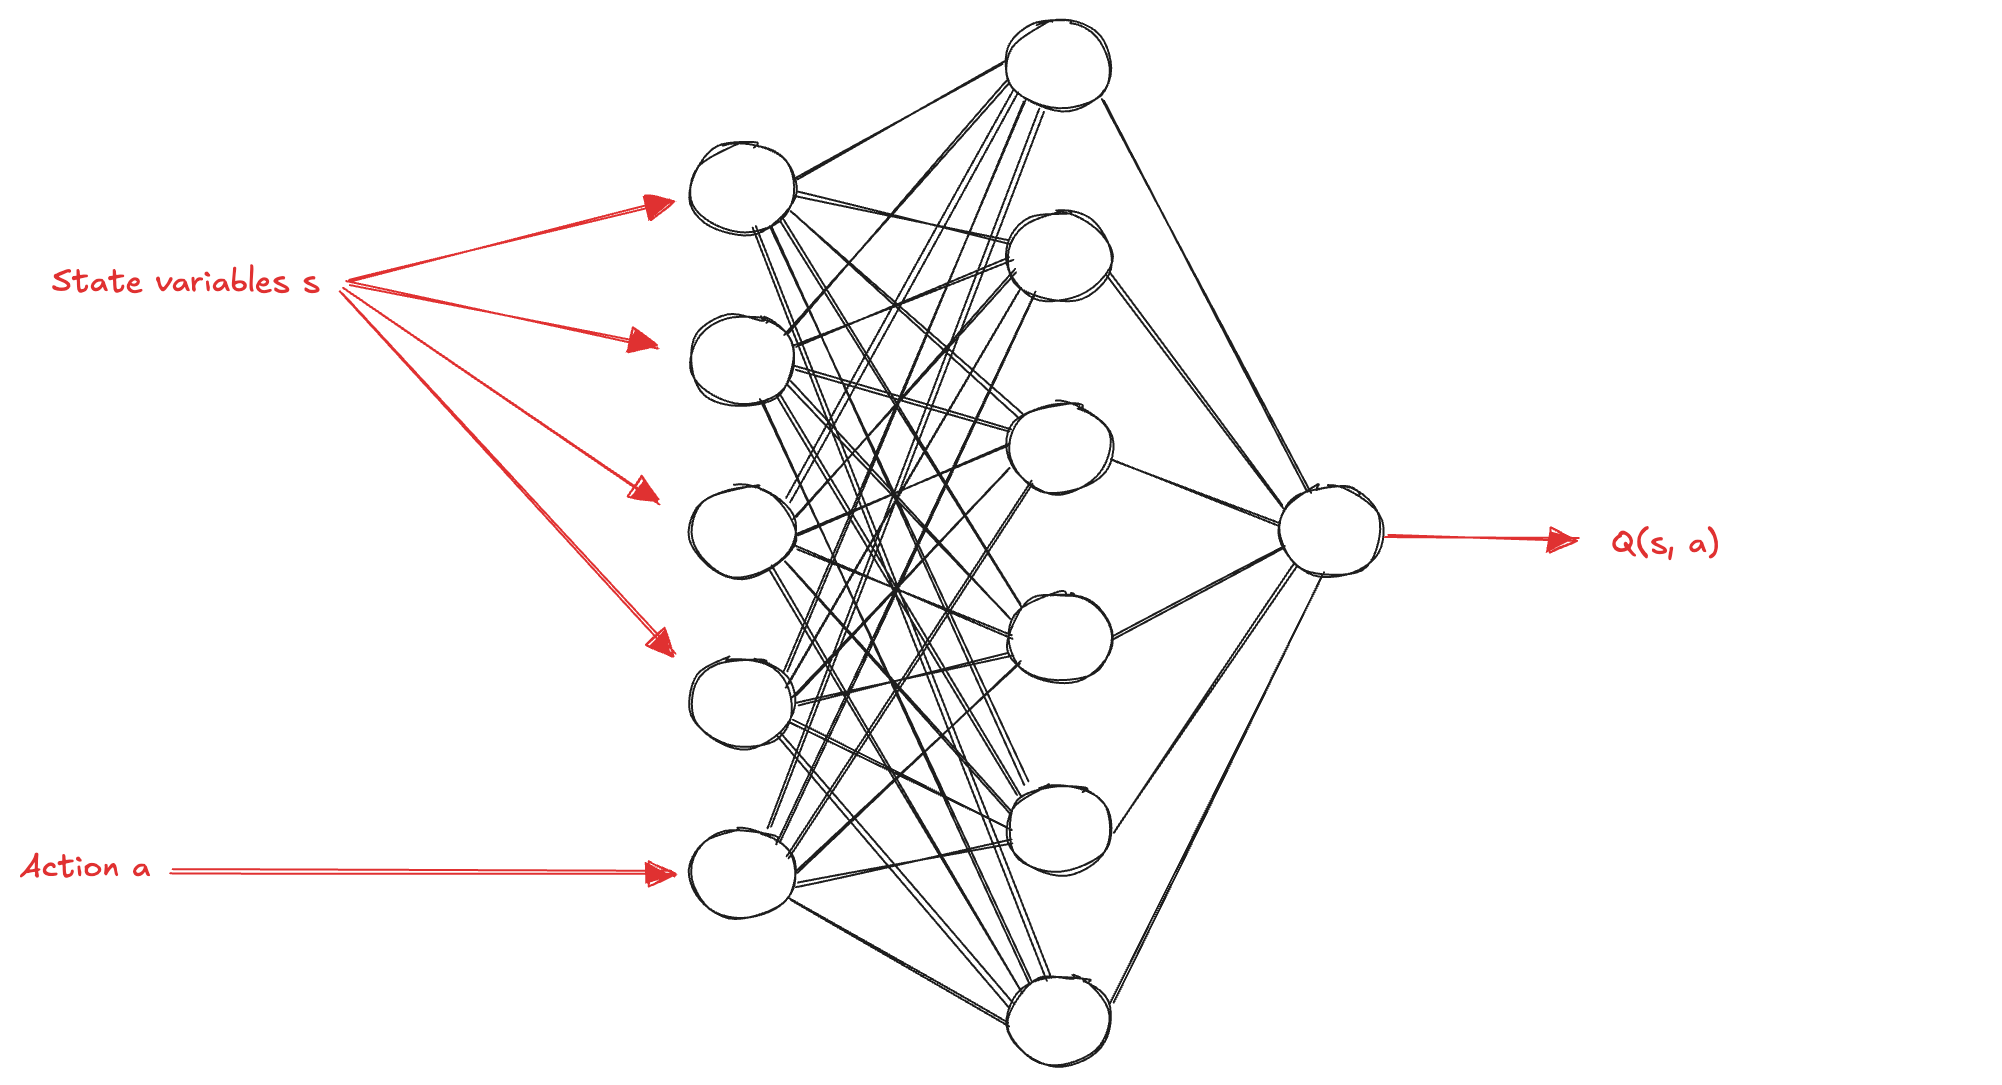

This architecture would work fine, but a more efficient one consists of **only inputting the state to the neural network and outputting the Q-values for all the actions** in that state:

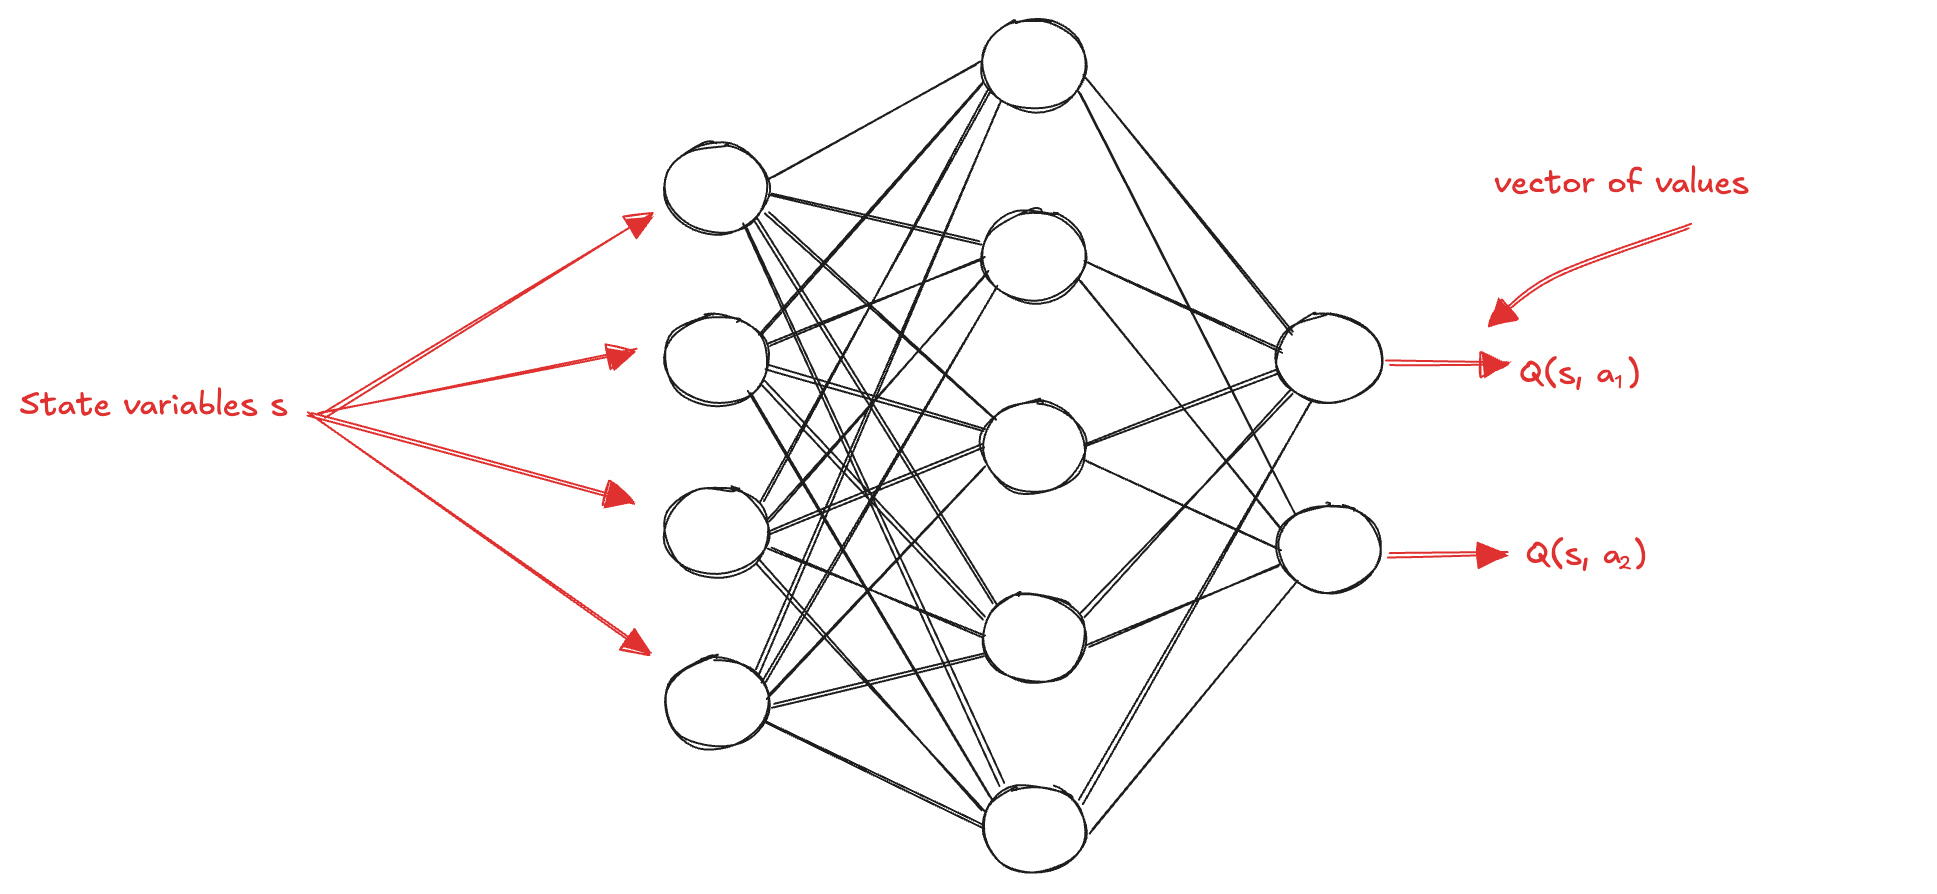

This is clearly advantageous when using exploration strategies such as epsilon-greedy or softmax, because we can have having to do **only one pass forward to get the values of all actions**. 

In a neural network-based approach, the state is passed through the network, which learns to approximate the action value function and the policy. This bypasses the need to explicitly store values for every state-action pair, as the network can generalize across states by learning patterns from the data. This generalization is critical in large or continuous environments where it’s impossible to enumerate or store all possible states. Moreover, the parameters of the DNN are learned through experience and adjusted using gradient-based optimization, allowing the policy to improve over time by tweaking the network’s internal weights. Thus, with this DNN-based method we can handle complex, high-dimensional spaces efficiently:

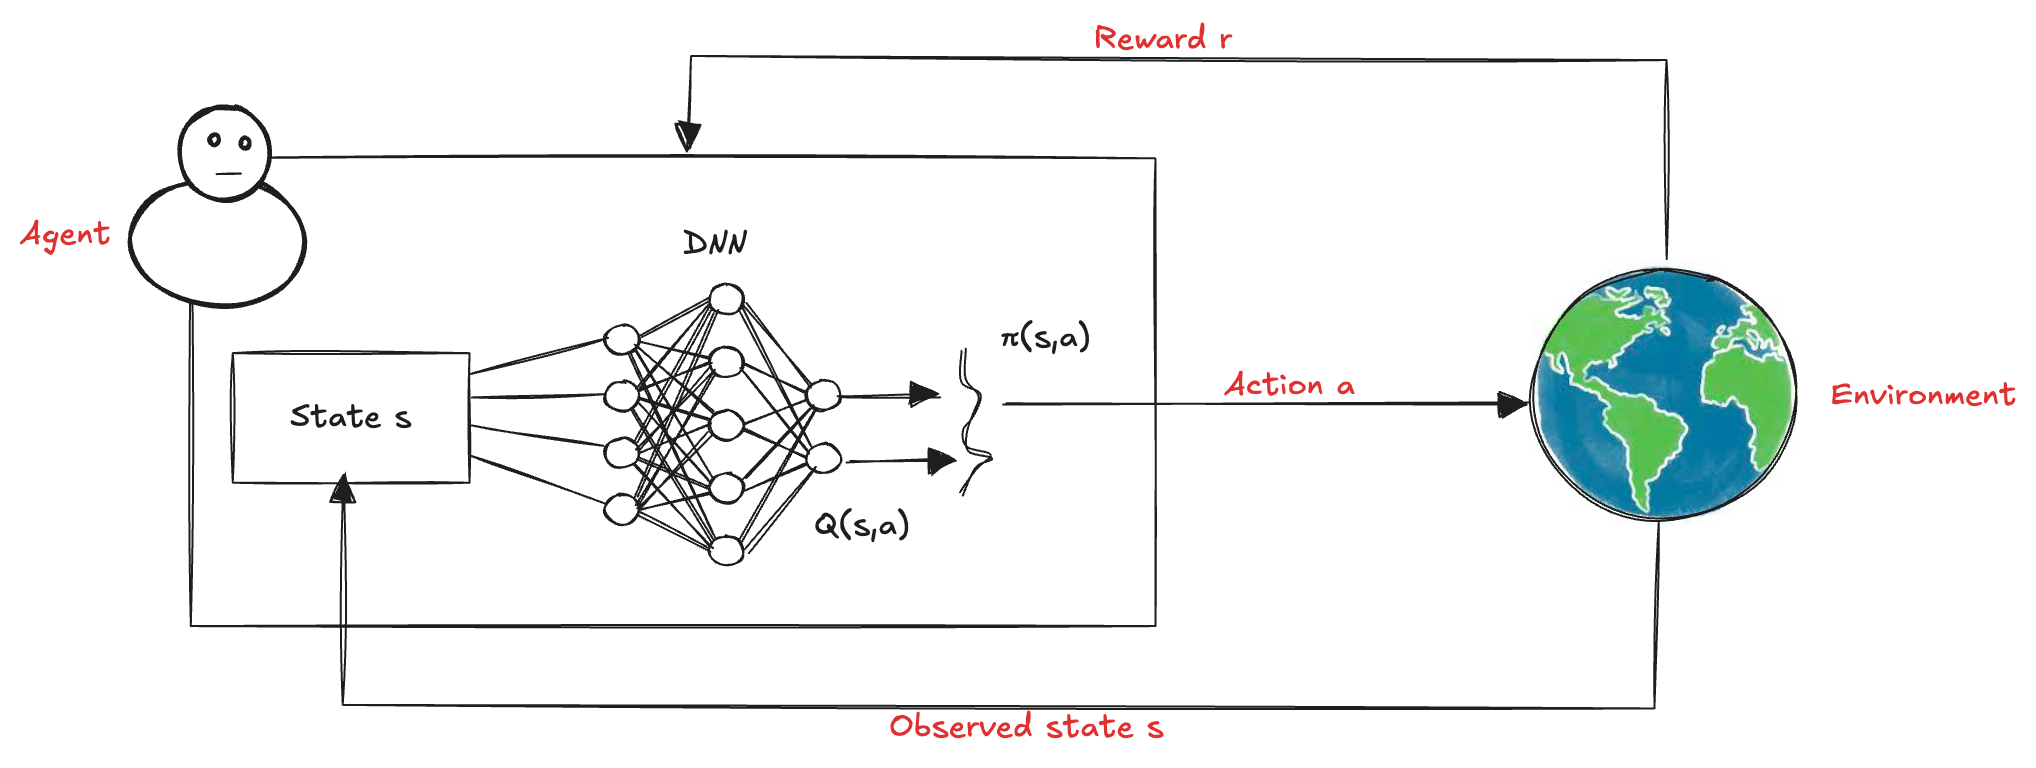

We can implement the function approximator as a **fully Connected network** using a machine learning library, such as PyTorch. The network will have two hidden layers with some neurons each (e.g. for the cartpole case 512 and 128 neuron are enough) and a ReLU activation function. The output layer will have a linear activation function, because we want to output the values directly. The input layer will have four neurons, one for each of the state variables: 

In [ ]:
import torch

# Define hyperparameters for the neural network
first_hidden_layer= 512;
second_hidden_layer= 128;

def create_network():

      # Define a deep neural network using Sequential:
      # Each layer feeds directly into the next one.
      dnn = torch.nn.Sequential( 
            # First fully connected layer maps state inputs to 512 hidden units
            torch.nn.Linear(state_size[0], first_hidden_layer),
            
            # ReLU activation introduces nonlinearity
            torch.nn.ReLU(),
            
            # Second fully connected layer (hidden layer with 128 units)
            torch.nn.Linear(first_hidden_layer, second_hidden_layer),
            
            # Another ReLU activation
            torch.nn.ReLU(),
            
            # Output layer: one unit per possible action
            # Produces Q-values
            torch.nn.Linear(second_hidden_layer, action_size)
      )
    
      # Return the constructed model
      return dnn;

In [10]:
q = create_network();

Using the neural network trained to estimate Q-values, we can define a greedy policy that always selects the action with the highest predicted value for the current state. This corresponds to acting optimally with respect to the current knowledge encoded in the network:

In [11]:
def nfq_pi(state):

    # convert state to a torch tensor
    state = torch.as_tensor(state, dtype=torch.float32)

    # compute Q-values from the network
    q_values = q(state).detach().numpy().squeeze()

    # select greedy action
    action = int(np.argmax(q_values))

    return action

## Training

To train a neural network we need to define a **Loss function**, which is a measure of how well a neural network predictions are. In supervised learning, it’s straightforward to define. We have a dataset of examples, and we know the correct output for each example. In that case, the loss function computes a distance score indicating how well the network has done on the datase. There are many different ways for calculating this distance score, one of the most common ones is MSE (**mean squared error**, or L2 loss). It is defined as the average squared difference between the "predicted" and "true" values. In our case, we have two problems. The first one is that **we don't have any dataset**, we need to collect experiences from the environment. The second one is that **we don't have access to the "true" values**. An ideal objective would be to calculate the loss with respect to the "true" (optimal) action-value function q* calulated over the experieces that we have collected:

$\displaystyle L(\theta)=E_{s,a}[(q_*(s,a)-Q(s,a;\theta))^2]$

Obviously, we are not talking about having access to q* (otherwise, there’s no need for learning), but we can use the same principles learned in generalized policy iteration, in which we **alternate between policy-evaluation and policy-improvement processes** to find good policies. However, because we’re using non-linear function approximation, **convergence guarantees no longer exist**. In the NFQ implementation we do just that: we start with a randomly initialized action-value function (and implicit policy), then we evaluate the policy by sampling actions from it, we improve it with an exploration strategy (such as epsilon-greedy) and finally, we keep iterating until we reach the desired performance. So, **we use as "true values" the targets**, which depend on a prediction also coming from the network, the value of the next state, in a circular dependency:

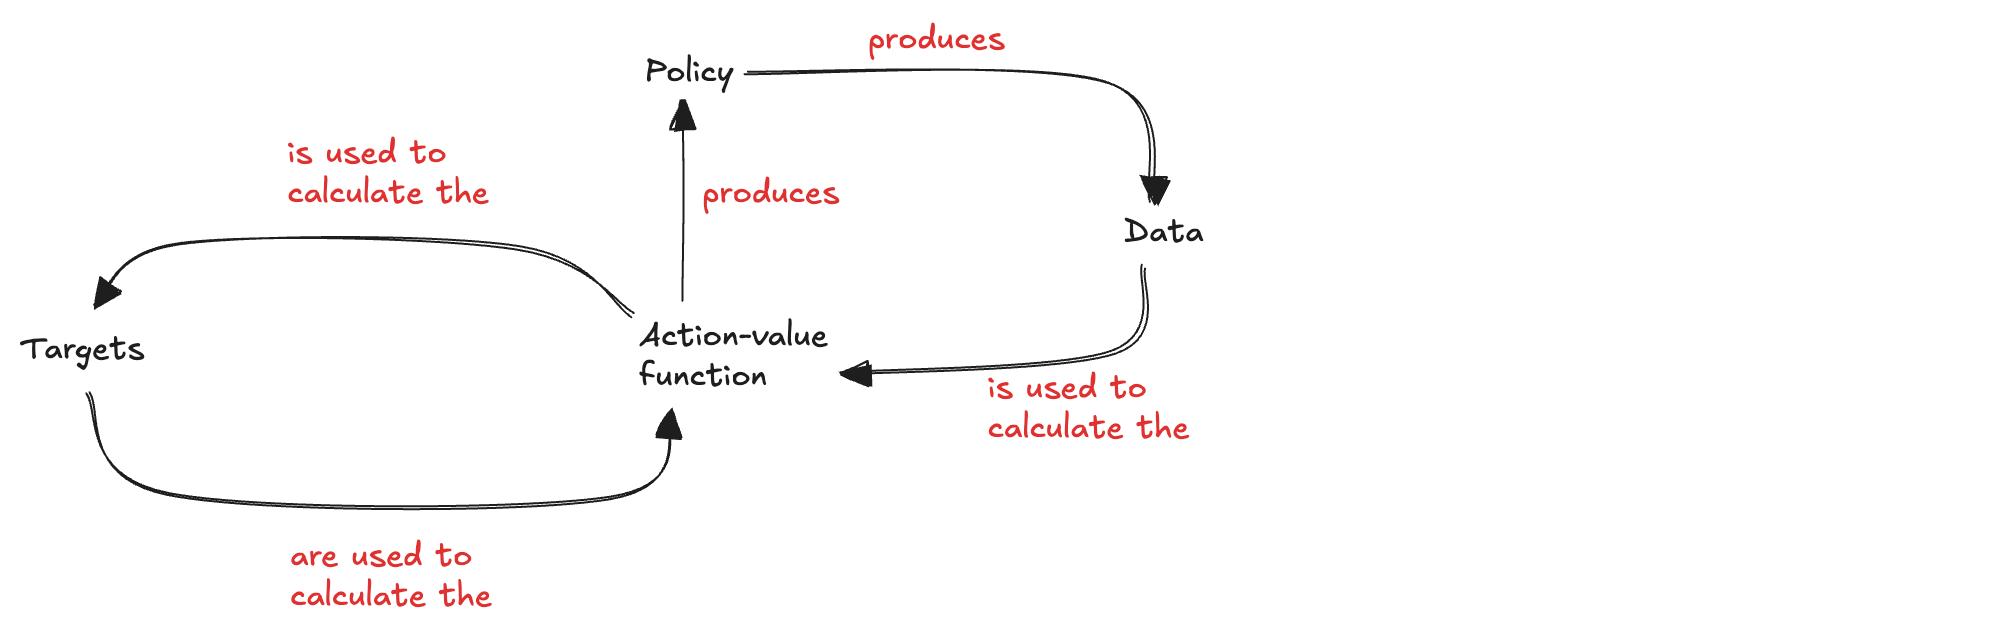

As you may be thinking, **this circular dependency is bad**. It’s not well behaved because **it doesn’t respect several of the assumptions made in supervised learning problems**. However, we can goes on and see what we can do with it. Ass your remember, there are different targets we can use for estimating the action-value function of a policy: Monte Carlo (MC) target, Temporal-Difference (TD) target, n-Step target, and Lambda target:

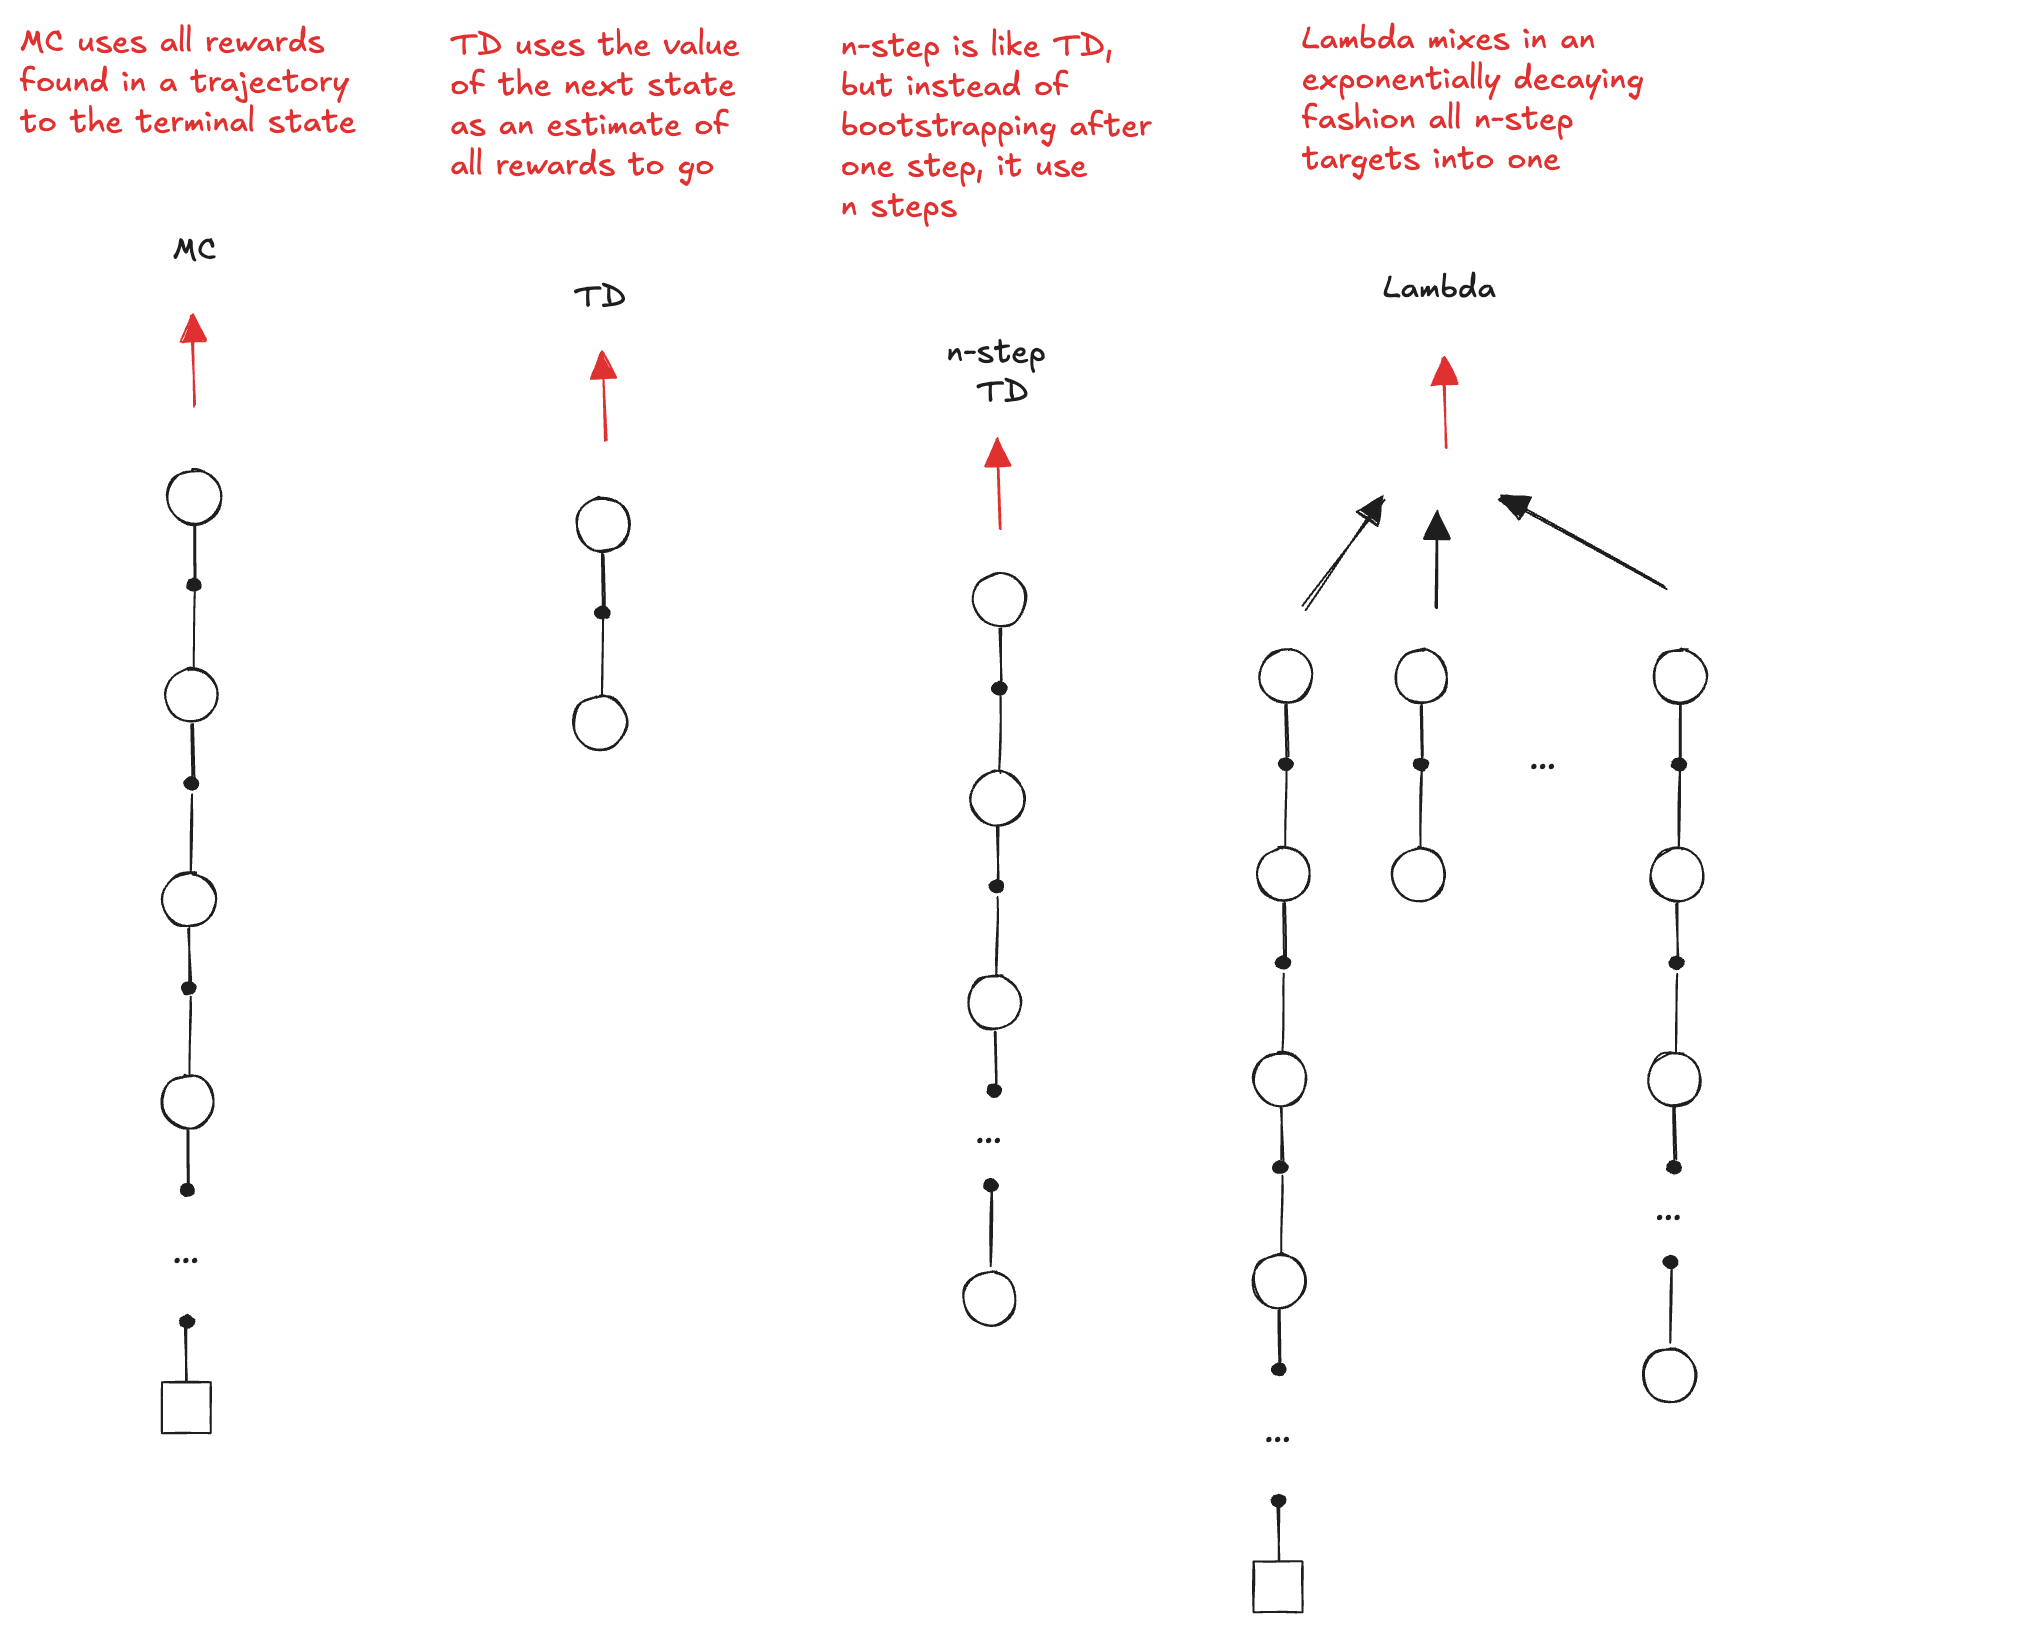

The target can be either on-policy (like in SARSA) or off-policy (like in Q-learning), depending on the way we bootstrap. The two main ways are to either use the action-value function of the action the agent will take at the landing state, or alternatively, to use the value of the action with the highest estimate at the next state:

$\displaystyle Q^\text{SARSA}(S_t, A_t) = Q(S_t, A_t) + \alpha  [ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) ]$

$\displaystyle Q^\text{Q-learning}(S_t, A_t) = Q(S_t, A_t) + \alpha [ R_{t+1} + \gamma  \underset{a}{\text{ max }} Q(S_{t+1}, a) - Q(S_t, A_t) ]$

Using those rules we can define the loss function as the difference between the current Q-value and the new value that should be assigned. For example, a squared-error measure like the following can be used:

$\displaystyle L(\theta)=E_{s,a} \left[ ( r + \gamma \underset{a}{\text{ max }} Q(s',a;\theta) - Q(s,a;\theta))^2 \right]$

In order to minimize the loss function we can use a standard optimization methods in supervised learning, like **Batch Gradient Descent (BGD)**, it takes the entire dataset at once, calculates the gradient of the dataset and steps toward this gradient a little bit at a time. Then, it repeats this cycle until convergence:

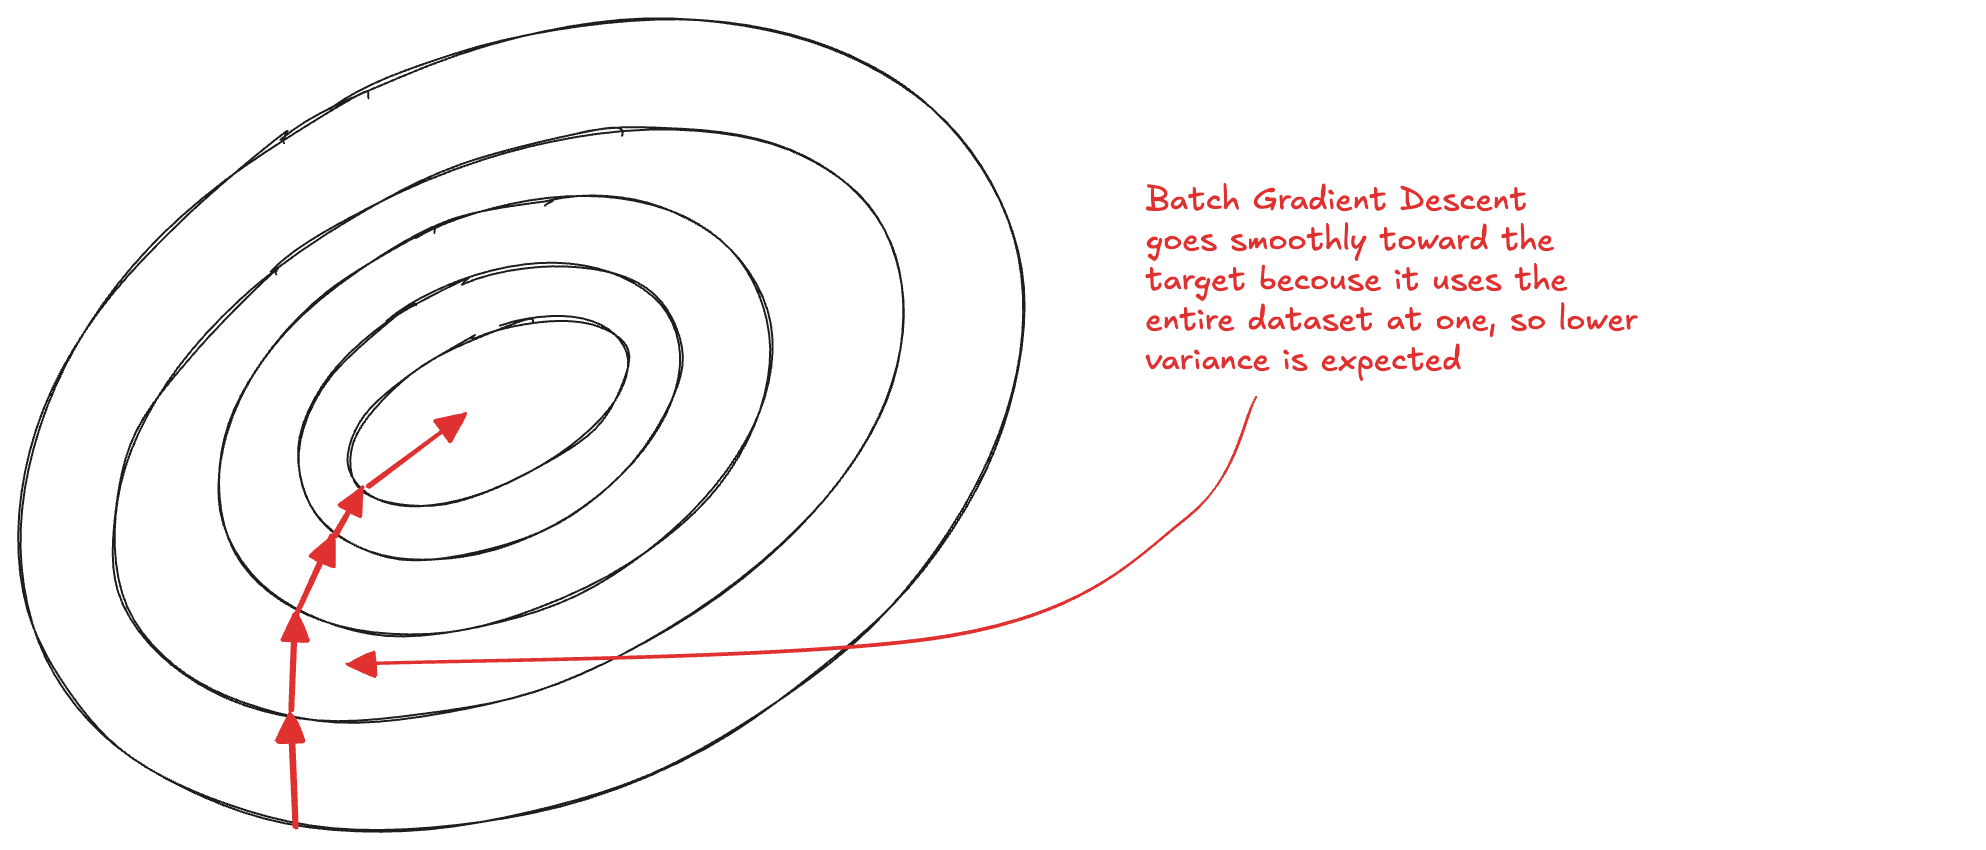


When we have a considerable dataset with millions of samples, BGD is too slow to be practical. Moreover, in reinforcement learning, **we don’t even have a dataset in advance, so batch gradient descent isn’t a practical method for our purpose**. An optimization method capable of handling smaller batches of data is called **Mini-Batch Gradient Descent (MGD)**, where we use only a fraction of the data at a time:

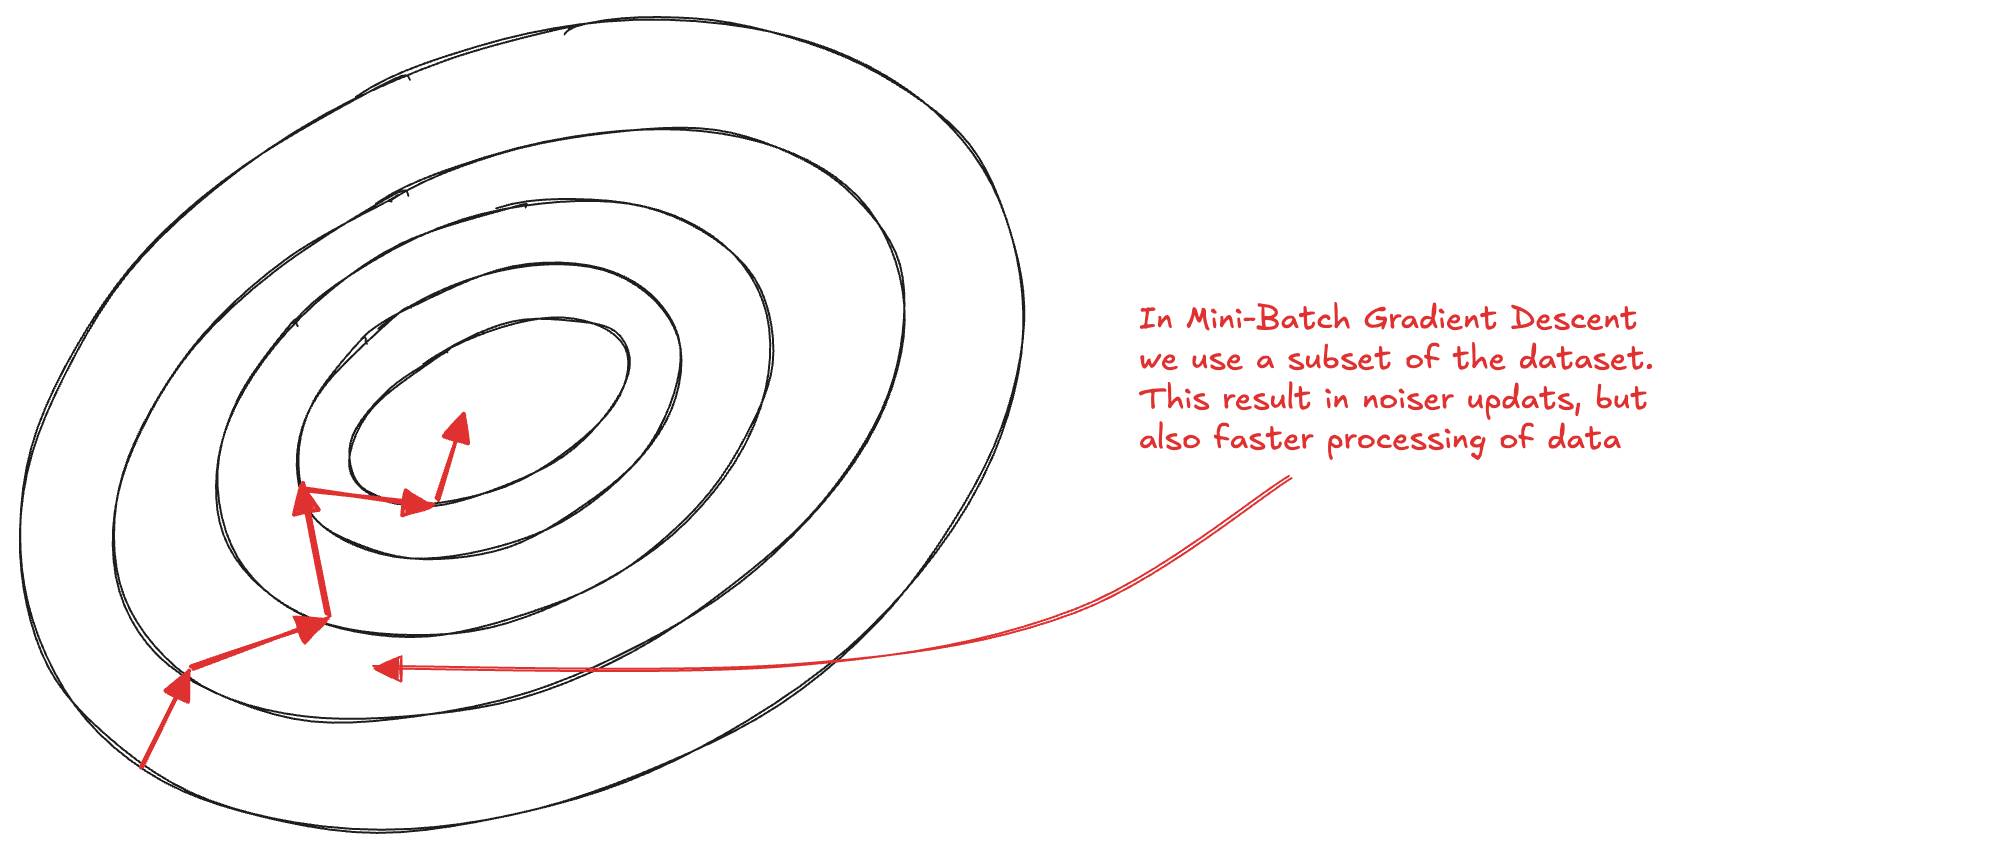

We can control the size of the mini-batches, which allows the processing of large datasets. At one extreme, we can set the size of mini-batch to the size of the dataset (BGD) at the other extreme, we can set the size to a single sample (**Stochastic Gradient Descent (SGD)**). The larger the batch, the lower the variance the steps of the optimization method have, but learning slows down considerably. An improved algorithm is called **Gradient Descent with Momentum**. This is a MBGD that updates the weights of the network in the direction of the moving average of the gradients, instead of the gradient itself:

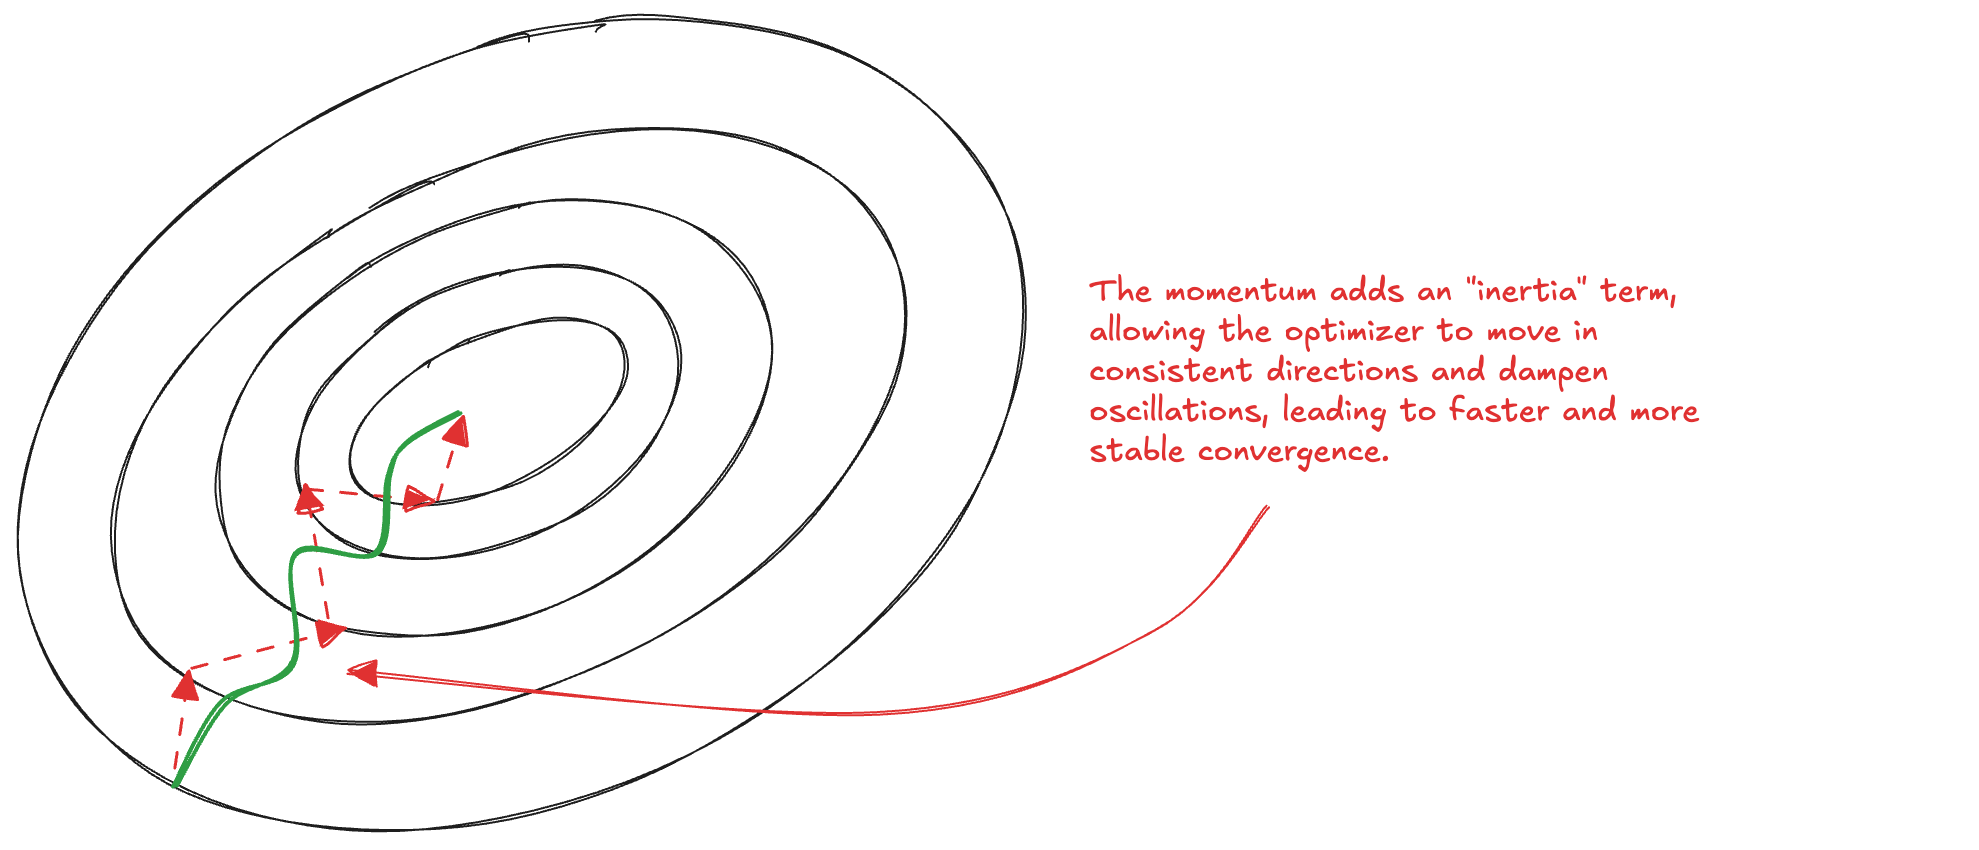

However, these algorithms require a couple of assumptions: data must be **independent and identically distributed (IID)** and targets must be **stationary**. In reinforcement learning we cannot ensure any of these assumptions. So choosing a robust optimization method to minimize the loss function can often make the difference between convergence and divergence. In practice, **Root Mean Square propagation (RMSprop)** (that reduces oscillations of Momentum by scaling the gradient in proportion to the average magnitude of recent gradients) and **Adaptive Moment Estimation (Adam)** (that steps in the direction of the velocity of the gradients as momentum, but it scales updates in proportion to the moving average of the magnitude of the gradients as RMSprop) are sensible choices for reinforcement learning:

In [12]:
learning_rate = 0.007;
optimizer = torch.optim.RMSprop(q.parameters(), lr=learning_rate);

All optimization methods are based on gradient calculation. It's important to note that when differentiating the loss function, the gradient is computed solely with respect to the predicted values, not the target values (this is a common source of error). In supervised learning, "predicted values" come from the model, while "true values" are constants provided in advance. In reinforcement learning, however, the "true values" depend on the predicted values themselves, as they are generated by the model. **Although this value is not a true constant, it should be treated as one during the optimization**:

$\displaystyle \nabla_{\theta_i} L(\theta)=E_{s,a} \left[ ( r + \gamma \underset{a}{\text{ max }} Q(s',a;\theta) - Q(s,a;\theta)) \nabla_{\theta} Q(s,a;\theta) \right]$

The problem with this on-line update rule is that if weights are adjusted for one certain state action pair, then unpredictable changes also occur at other places in the state-action space. Although in principle this could also have the positive effect of generalization, in many cases this seems to be the main reason for unreliable and slow learning. So the basic idea of NFQ is to  **update the neural value off-line, considering an entire set of transition experiences**. So we need to store a collection of experiences:

In [13]:
# define the batch size
batch_size = 1024;

# define the structured dtype for an experience tuple
experience_type = np.dtype([
    ('state',      np.float32, state_size),   # current state
    ('action',     np.int8),                  # action taken
    ('reward',     np.float32),               # reward received
    ('next_state', np.float32, state_size),   # next state
    ('failure',    np.int8)                   # terminal flag (1 if done)
])

To train the agent, we must collect batches of experiences by interacting with the environment.
During this phase, we use an **exploration strategy** to balance the trade-off between exploring new actions and exploiting what the agent has already learned. The common choice is the epsilon-greedy policy:

In [14]:
# Exploration vs exploitation parameter
epsilon = 0.5

def epsilon_greedy(state):

    # Exploration
    if random.random() < epsilon:
        action = random_pi(state)

    # Exploitation
    else:
        action = nfq_pi(state)
        
    return action

We can now train the neural network by using the experiences collected from the environment to update its parameters. This is done by computing the loss function (which measures the discrepancy between predicted and target Q-values) and applying the backpropagation algorithm to adjust the network weights accordingly:

In [ ]:
# define the discount factor
gamma = 0.99;

# define the number of optimization epochs
epochs = 40;

def optimize(batch):

    # convert experience fields to tensors
    states      = torch.from_numpy(batch['state'].copy()).float()        
    actions     = torch.from_numpy(batch['action'].copy()).long()        
    rewards     = torch.from_numpy(batch['reward'].copy()).float()       
    next_states = torch.from_numpy(batch['next_state'].copy()).float()   
    failures    = torch.from_numpy(batch['failure'].copy()).float()      

    # perform multiple epochs of optimization
    for epoch in range(epochs):

        # compute target: r + γ * max_a Q(next_state, a') * (1 - done)
        # remember to detach, we need to treat these values as constants! 
        with torch.no_grad():
            q_next = q(next_states);               
            max_q_next = q_next.max(dim=1).values;
            target = rewards + gamma * max_q_next * (1.0 - failures);

        # compute current Q(s, a)
        q_current_all = q(states);
        q_current = q_current_all.gather(1, actions.unsqueeze(1)).squeeze(1);

        # computer the Mean Squared TD Error loss
        td_error = target - q_current;

        # compute the loss
        loss = (td_error ** 2).mean();

        # optimize network parameters
        optimizer.zero_grad();
        loss.backward();
        optimizer.step();
        
        return loss;


## NFQ Algorithm

Now we can put things together and consider the full algorith: 

1. use a fully connected neural network with states as input and actions as output; 
2. use an epsilon-greedy strategy to explore the environment and to collect some experiences (e.g. 1024 samples);
3. calculate the off-policy targets;
4 fit the action-value function using MSE for the loss function and RMSprop as optimizer;
4. repeats steps 3 and 4 a number of times (epochs) before going back to step 2;

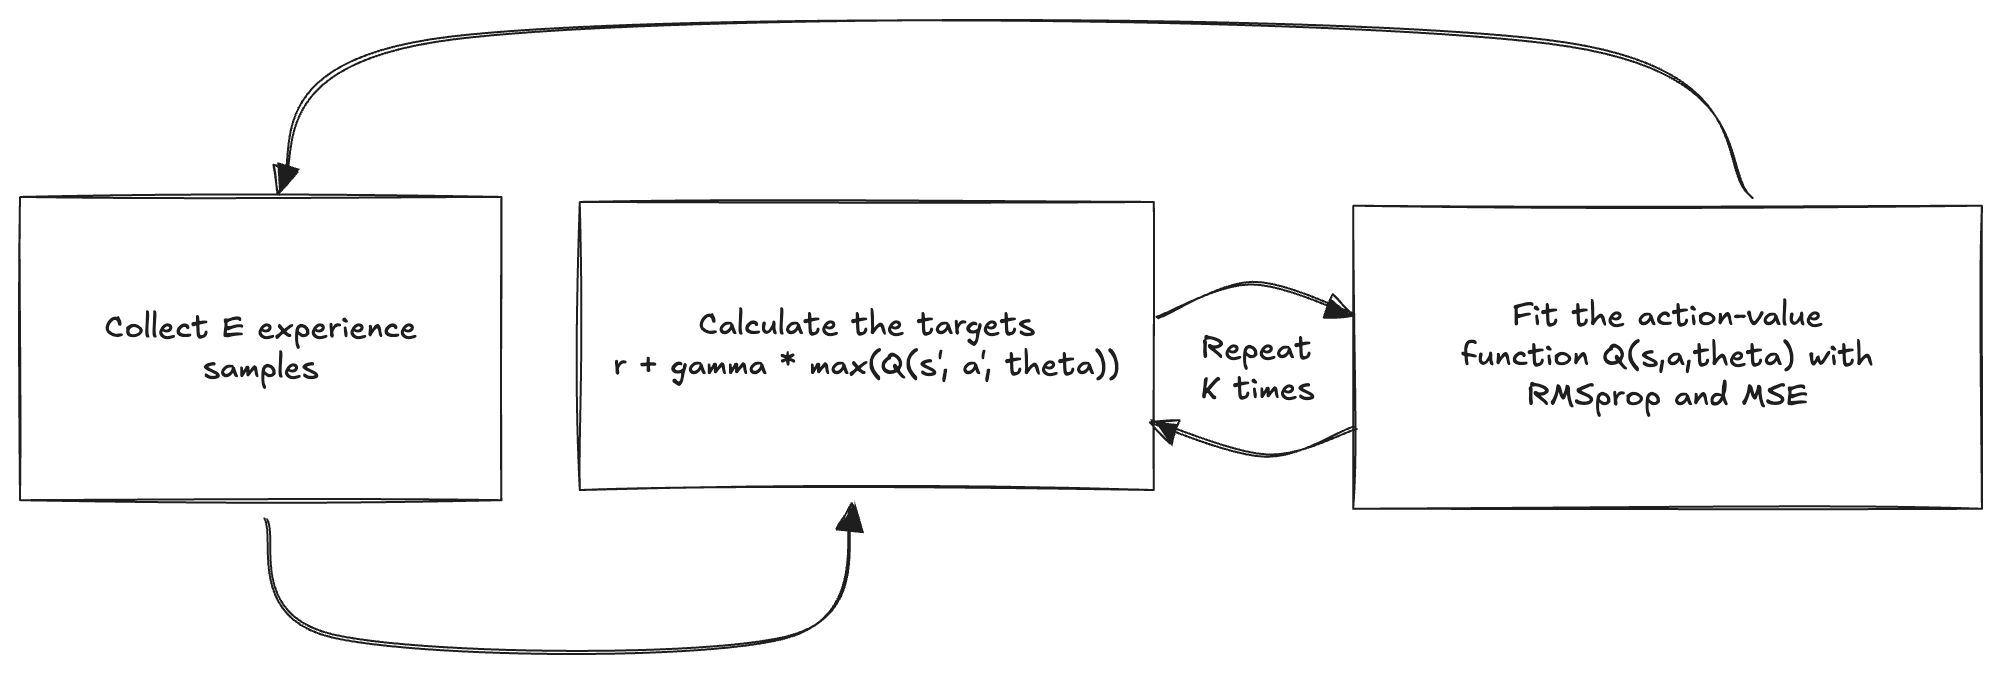

We can write this process and apply it to the Cart-pole environment:

In [16]:
def nfq(max_episodes):

    # create a batch index
    index = 0;

    # create a score tracker for statistic purposes
    scores = [];

    # create an empty experience batch
    experiences_batch = np.empty(batch_size, dtype=experience_type);

    # train until the maximum number of episodes
    for episode in range(max_episodes):

        # reset the environment at the beginning of the episode
        state, _ = env.reset();
        done = False;

        # interact with the environment until the episode is done
        while not done:
                
            # select the action using the exploration policy
            action = epsilon_greedy(state);

            # perform the selected action
            next_state, reward, terminal, truncated, _ = env.step(action);
            done = terminal or truncated;
            failure = terminal and not truncated;

            # store the experience
            experiences_batch[index] = (state, action, reward, next_state, failure);
            index += 1;
            
            # if the experience collected so far is enough...
            if index == len(experiences_batch):
                # optimize the model
                optimize(experiences_batch);
                # and clear the buffer
                index = 0;
                experiences_batch = np.empty(shape=(len(experiences_batch),), dtype=experience_type);

            # update current state to next state
            state = next_state;

        # After each episode, evaluate the policy
        score = evaluate(nfq_pi, episodes=10);

        # store the score in the tracker
        scores.append(score);
        
        # print some informative logging 
        message = 'Episode {:03}, score {:05.1f}';
        message = message.format(episode+1, score);
        print(message, end='\r', flush=True);
        
    return scores;

We can apply the algorithm to the Cart-pole environment:

In [17]:
nfq(max_episodes = 600);

We can evaluate the performance of the learned agent versus the random one:

In [18]:
agent_score = evaluate(nfq_pi, episodes=10);

print("Random score", random_score);
print("Agent score", agent_score);

Random score 23.51
Agent score 500.0


And we can see the agent in action:

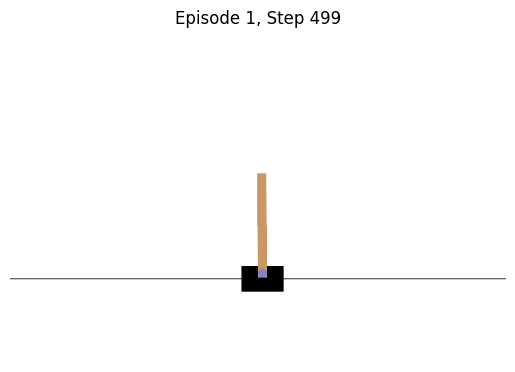

In [19]:
show_policy(nfq_pi, n_episodes=1, max_steps=500);

The agent is good enough to balance the pole for a considerable amount of time. Howerver, we don't have any information about the performance of the algorithm, we can try to understand how the agent is learning by plotting some quantities over time setting up an experiment.

## Experiment

To better understand how the agent learns over time, we can weite a function to run a series of trainings and track the average score achieved by the algorithm after a fixed number of episodes. By repeating the experiment multiple times with different random seeds, we can assess the stability and robustness of the learning process. This helps determine whether the algorithm converges reliably or if its performance depends heavily on random initialization.

In [20]:
import joblib

def experiment(max_episodes):

    global q, optimizer;

    # List of random seeds to test algorithm stability
    seeds = (12, 34, 56, 78, 90);

    # Container to collect all experiment results
    results = [];

    # Run an independent training experiment per seed
    for seed in seeds:
    
        print("Experiment seed: ", seed);
            
        # Set all relevant random seeds for reproducibility
        torch.manual_seed(seed);
        np.random.seed(seed);
        random.seed(seed);

        # reset the environment
        env.reset(seed=seed);
        env.action_space.seed(seed)
        env.observation_space.seed(seed)

        # create a new model
        q = create_network();
        optimizer = torch.optim.RMSprop(q.parameters(), lr=learning_rate);

        # train the network
        scores = nfq(max_episodes);
            
        # smooth the result using a sliding window
        sliding_windows = 25;
        scores = np.convolve(scores, np.ones(sliding_windows)/sliding_windows, mode='valid');
            
        # collect the results
        results.append(scores);

        print("");

     # calculate max, min and average scores among experiments
    max_score = np.max(results, axis=0).T;
    min_score = np.min(results, axis=0).T;
    mean_score = np.mean(results, axis=0).T;

    # prepare the results
    experiment_results = {
        'max_score': max_score,
        'min_score': min_score,
        'mean_score': mean_score
    }

    # Save results
    joblib.dump(experiment_results, './nfq_results.joblib');

    return experiment_results;

We now define a specific set of hyperparameters controlling both the training process and the neural network architecture, and we execute a single training experiment to observe how the agent’s performance evolves over time under these conditions:

In [21]:
# Define the experiment setup and hyperparameters
gamma = 0.99;               # discount factor
learning_rate = 0.0005;      # step size for the optimizer
batch_size = 1024;          # number of experiences per batch
epochs = 16;                # optimization steps per batch
epsilon = 0.5               # esploration vs exploitation parameter
first_hidden_layer = 256;   # size of the first hidden layer
second_hidden_layer = 128;  # size of the second hidden layer

# Run the experiment
results = experiment(max_episodes=1500);

Experiment seed:  12


Episode 1500, score 321.3
Experiment seed:  34
Episode 1500, score 485.7
Experiment seed:  56
Episode 1500, score 408.6
Experiment seed:  78
Episode 1500, score 473.6
Experiment seed:  90
Episode 1500, score 441.8


While NFQ cannot be considered a state-of-the-art solution, it demonstrates decent performance in relatively simple environments like CartPole. As observed during the simulations, the algorithm converges differently when initialized with various random seeds. This variability indicates that the algorithm lacks stability, resulting in significant fluctuations in performance.  We perform basic statistical analysis on the experimental data to calculate the maximum, minimum, and mean scores for each step. This helps us assess both the stability of the performance (how close the scores are to the mean) and its quality (how close the scores are to the maximum). we can plot the average scores obtained by the agent over different training episodes:

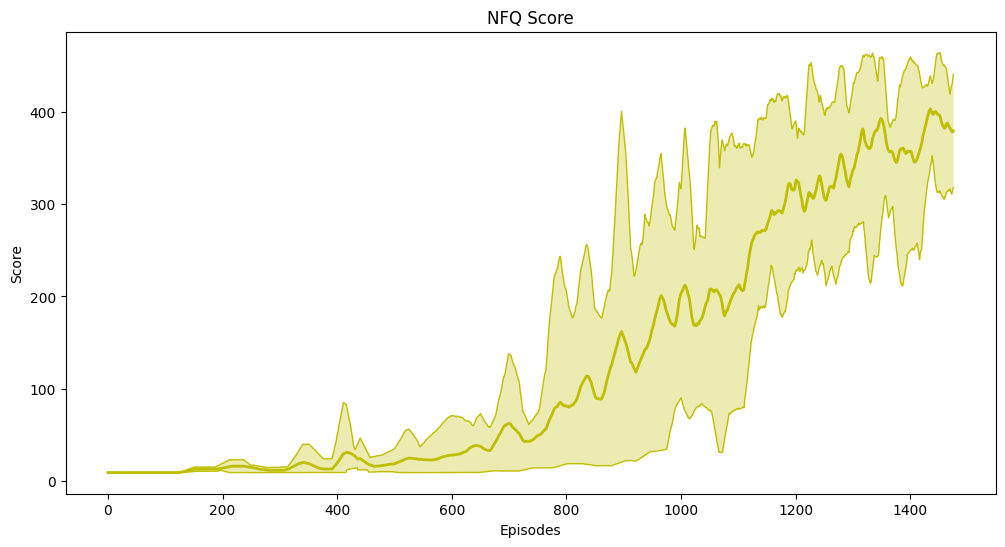

In [22]:
plt.figure(figsize=(12,6));
plt.title('NFQ Score');
plt.ylabel('Score');
plt.xlabel('Episodes');
episodes = range(len(results['max_score']));
plt.plot(results['max_score'], 'y', linewidth=1)
plt.plot(results['min_score'], 'y', linewidth=1)
plt.plot(results['mean_score'], 'y', linewidth=2)
plt.fill_between(episodes, results['max_score'], results['min_score'], facecolor='y', alpha=0.3);
plt.show();

The NFQ algorithm shows learning progress as the score increases, but there is **some instability** as indicated by the **high variance** in the scores and the growing gap between the max and min scores. The sliding average helps to highlight the trend in the data, showing that the agent is learning to balance the pole more effectively over time. Overall, in this simple environment, the algorithm is able to learn a good policy in a relatively short amount of time.

## Challenges

There are two main issues with the NFQ algorithm. First, although we use a powerful function approximator capable of generalizing across many state–action pairs (which is a strength) this same property becomes a **source of instability**. The neural network updates the values of all similar states at once, and since our target values depend on the estimated values of the next state, the **learning targets themselves are non-stationary**. Each time the network’s weights are updated, the targets shift as well, immediately invalidating the most recent update. This feedback loop causes **the training process to quickly become unstable**, as illustrated below:

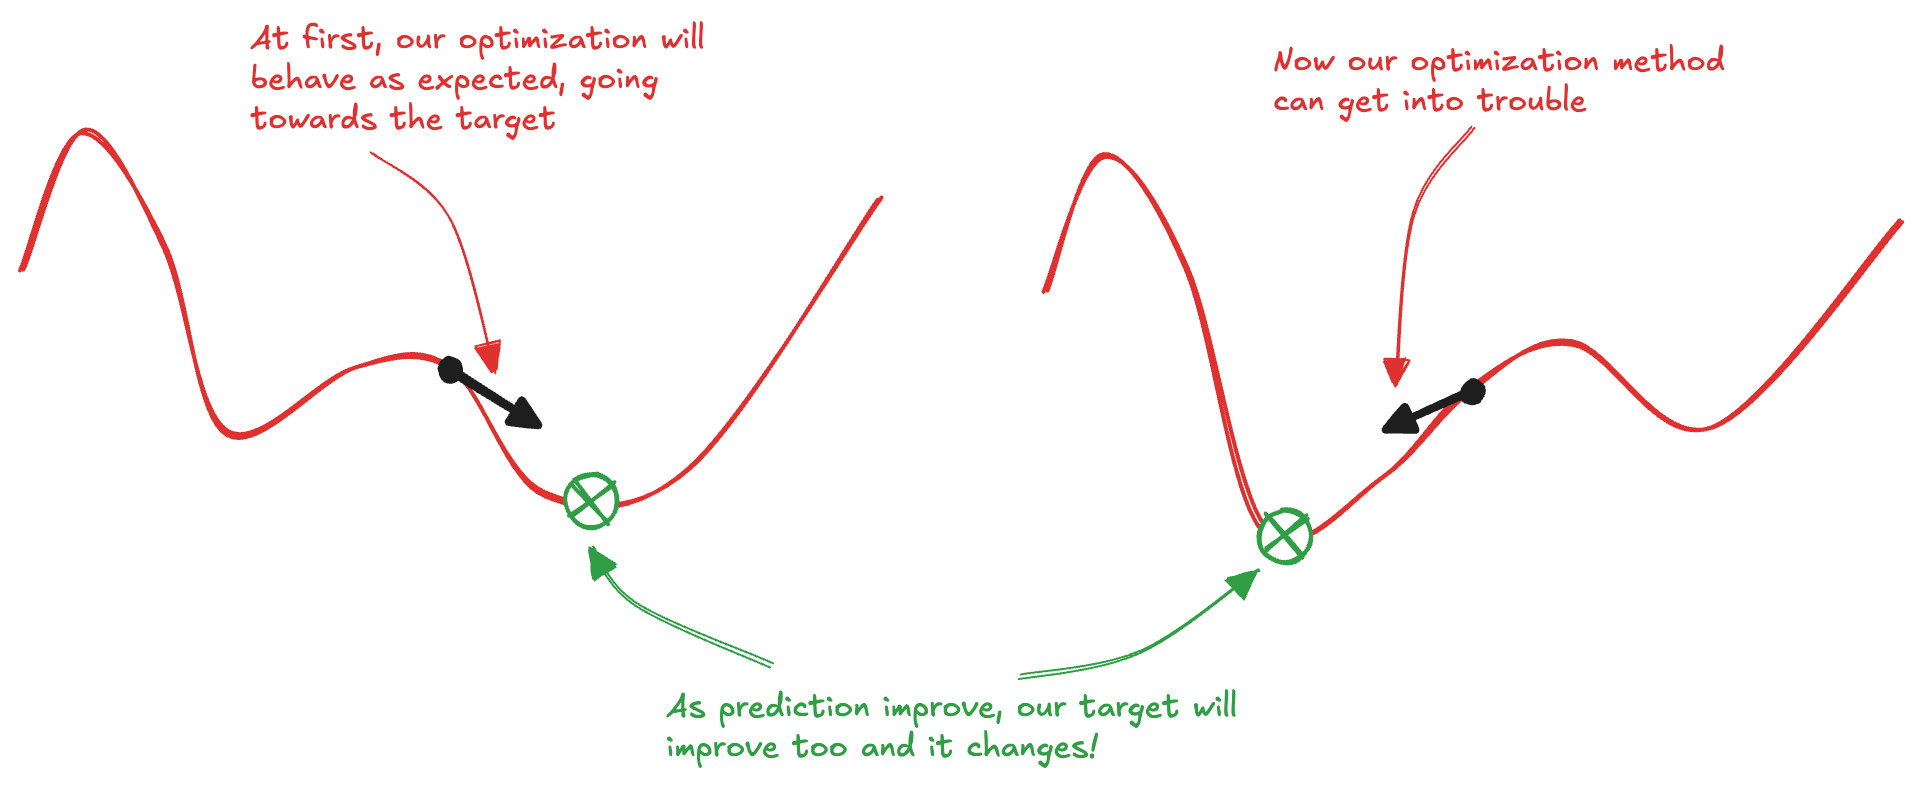

NFQ mitigates this instability through the use of **batch learning**. Instead of updating the network after each individual experience, NFQ collects a batch of experiences and optimizes the network on this larger, more diverse set. Larger batches help by smoothing out noise and providing broader coverage of the state–action space. However, this approach introduces a second problem: **correlated samples**. The collected experiences come from consecutive time steps within the same trajectory and policy, meaning they are **not independent**. Consequently, the network learns from batches that violate the **IID (independent and identically distributed) assumption fundamental to most optimization methods**. In reinforcement learning, **samples are not independent** (each state depends on the previous one) and **not identically distributed** (the policy generating the data changes over time). While gradient-based optimizers can tolerate limited departures from IID conditions, reinforcement learning breaks this assumption almost entirely, requiring additional techniques to stabilize learning.

To better understand how hyperparameter choices affect NFQ’s performance and stability, we can conduct a systematic **grid search** by running multiple experiments with different configurations. The following code iterates over selected hyperparameter values, runs a complete experiment for each setup, and saves the corresponding learning curves as images. By comparing these saved plots, we can analyze how various settings influence learning speed, convergence, and robustness. We rank the results based on the **average score over the entire learning process**, which provides higher values to runs whose learning curves stay consistently high throughout training, rather than just peaking at the end. This metric helps **identify hyperparameter combinations that yield stable and effective learning** across the entire training duration:

In [ ]:
import itertools

def run_grid_experiments(param_grid, max_episodes):

    global gamma, batch_size, epochs, epsilon, learning_rate, first_hidden_layer, second_hidden_layer

    # Extract the parameter names and their values, 
    # itertools.product to get all combinations
    keys = list(param_grid.keys())
    combos = list(itertools.product(*(param_grid[k] for k in keys)))
    total = len(combos)
    
    print(f"Running {total} experiments...")

    # Store a summary of all experiments
    summary = []

    # Run each experiment
    for idx, combo in enumerate(combos, start=1):

        # Get the parameters for this experiment
        params = dict(zip(keys, combo))

        # Print the experiment details
        print(f"\nExperiment {idx}/{total}")
        for k, v in params.items():
            print(f"   {k:>20s} = {v}")
        print("")

        # Run the experiment with the current parameters
        gamma=params["gamma"]
        batch_size=params["batch_size"]
        epochs=params["epochs"]
        epsilon=params["epsilon"]
        learning_rate=params["learning_rate"]
        first_hidden_layer=params["first_hidden_layer"]
        second_hidden_layer=params["second_hidden_layer"]

        exp_res = experiment(max_episodes=max_episodes)

        # Extract learning curve
        mean_score = exp_res["mean_score"]
        min_score = exp_res["min_score"]
        max_score = exp_res["max_score"]      

        # Compute metrics
        avg_mean = float(np.mean(mean_score))
        final_mean = float(mean_score[-1])

        # Build a descriptive title string
        title_str = (
            f"NFQ Learning Performance (Exp {idx}/{total})\n"
            f"γ={params['gamma']}, lr={params['learning_rate']}, "
            f"bs={params['batch_size']}, ep={params['epochs']}, "
            f"ε={params['epsilon']}, h1={params['first_hidden_layer']}, "
            f"h2={params['second_hidden_layer']}"
        )

        # Generate the plot
        plt.figure(figsize=(12, 6))
        plt.title(title_str, fontsize=10)
        plt.ylabel('Score')
        plt.xlabel('Episodes')
        episodes = range(len(mean_score))
        plt.plot(mean_score, color='orange', linewidth=2, label='Mean score')
        plt.fill_between(episodes, min_score, max_score, 
                         color='orange', alpha=0.3, 
                         label='Range (min–max)')
        plt.legend()
        plt.tight_layout()

        # Create a filename based on parameters and save
        filename = (f"nfq_gamma{params['gamma']}_"
                    f"lr{params['learning_rate']}_"
                    f"bs{params['batch_size']}_"
                    f"ep{params['epochs']}_"
                    f"eps{params['epsilon']}_"
                    f"h1_{params['first_hidden_layer']}_"
                    f"h2_{params['second_hidden_layer']}.png").replace('.', '_')
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()

        # Append the summary
        summary.append({
            "index": idx,
            **params,
            "avg_mean": avg_mean,
            "final_mean": final_mean
        })

    # Sort by average score
    summary.sort(key=lambda r: (r["avg_mean"], r["final_mean"]), reverse=True)

    # Print the best configuration 
    print("\nAll experiments completed.")
    print(f"Best configuration (by average mean score): Experiment {summary[0]['index']}")
    print(summary[0])

    # Return the summary of all experiments
    return summary

Do not run this code directly in the notebook, as it is computationally intensive.

In [37]:
param_grid = {
    "gamma": [0.99, 1.00],
    "learning_rate": [0.0005, 0.001, 0.001, 0.005],
    "batch_size": [256, 512, 1024, 2048],
    "epochs": [8, 16, 32, 64, 128],
    "epsilon": [0.4, 0.5, 0.7],
    "first_hidden_layer": [128, 256, 512],
    "second_hidden_layer": [64, 128, 256]
}

#summary = run_grid_experiments(param_grid, max_episodes=1000)

In the following images, you can see some of the learning curves obtained with different hyperparameter combinations:

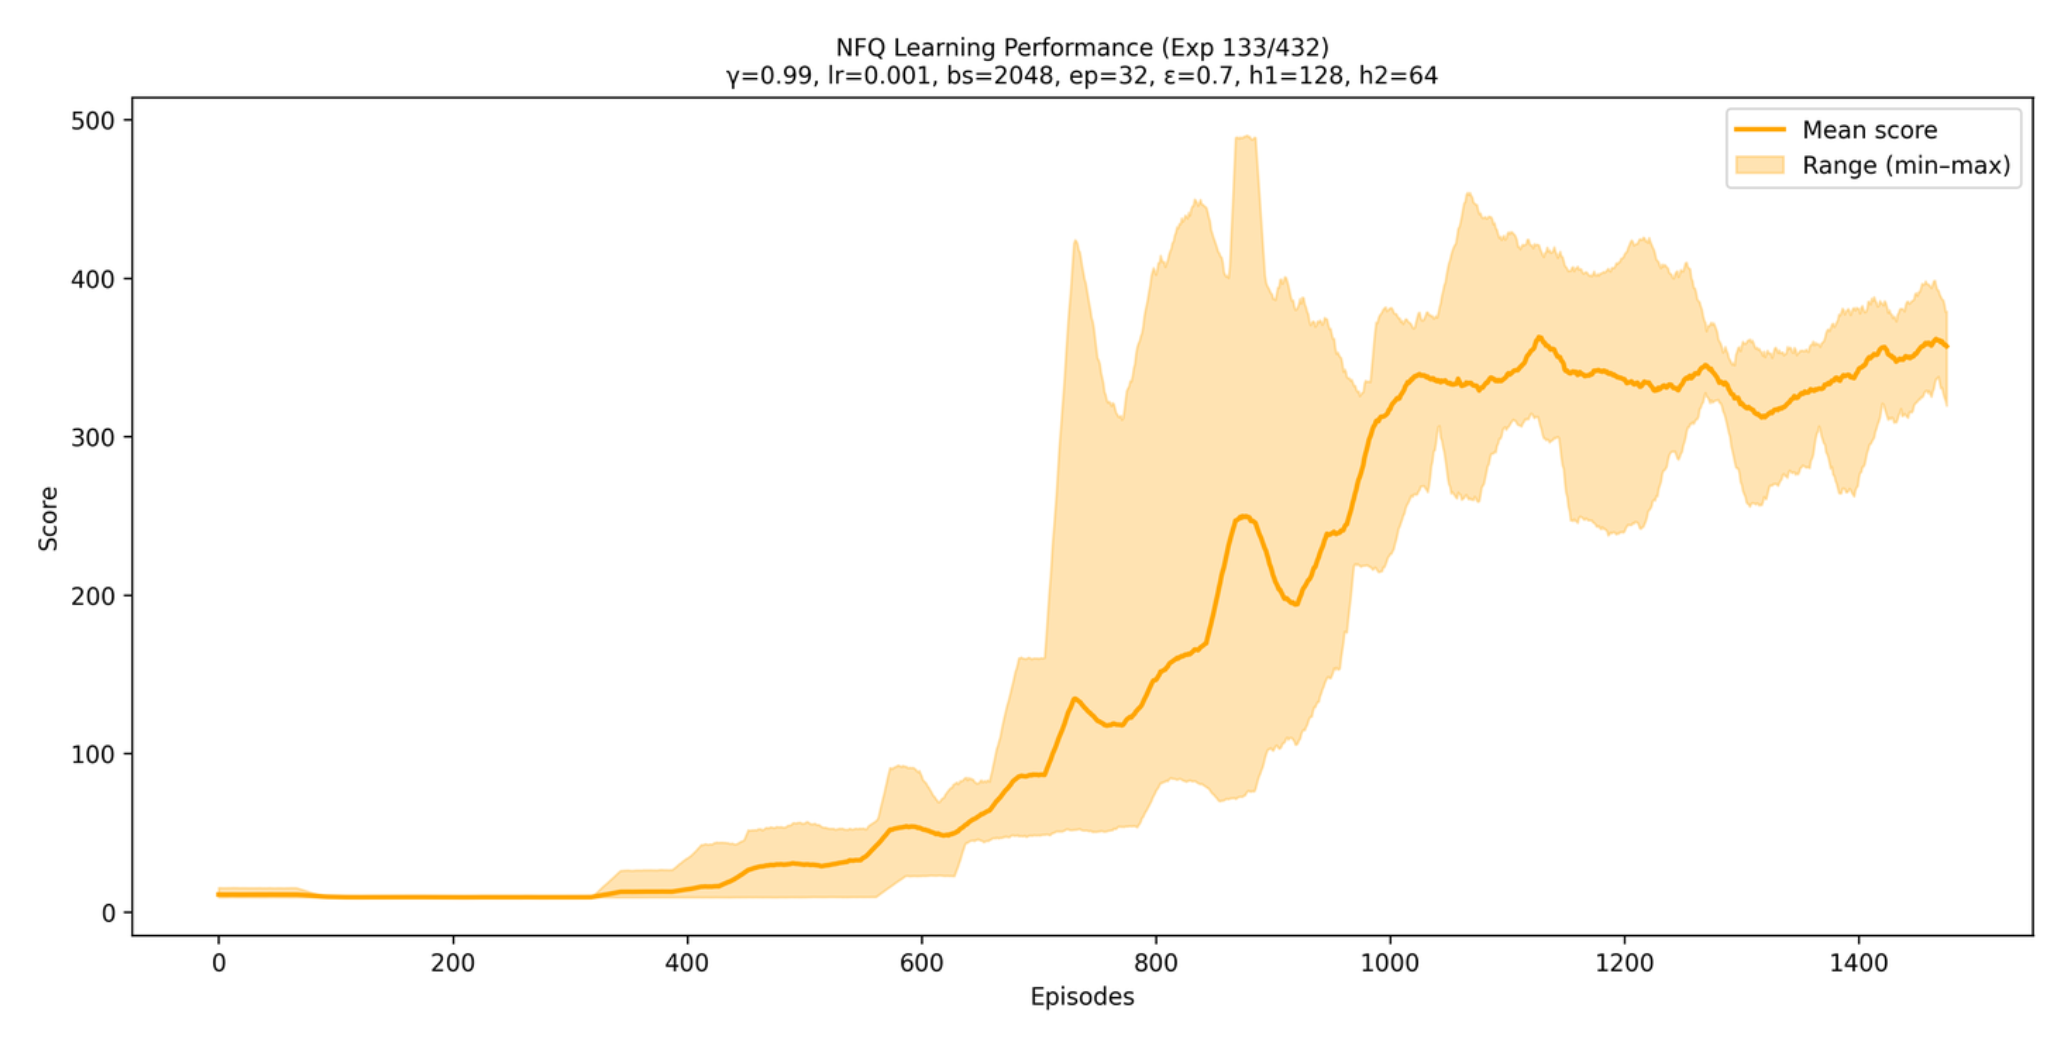

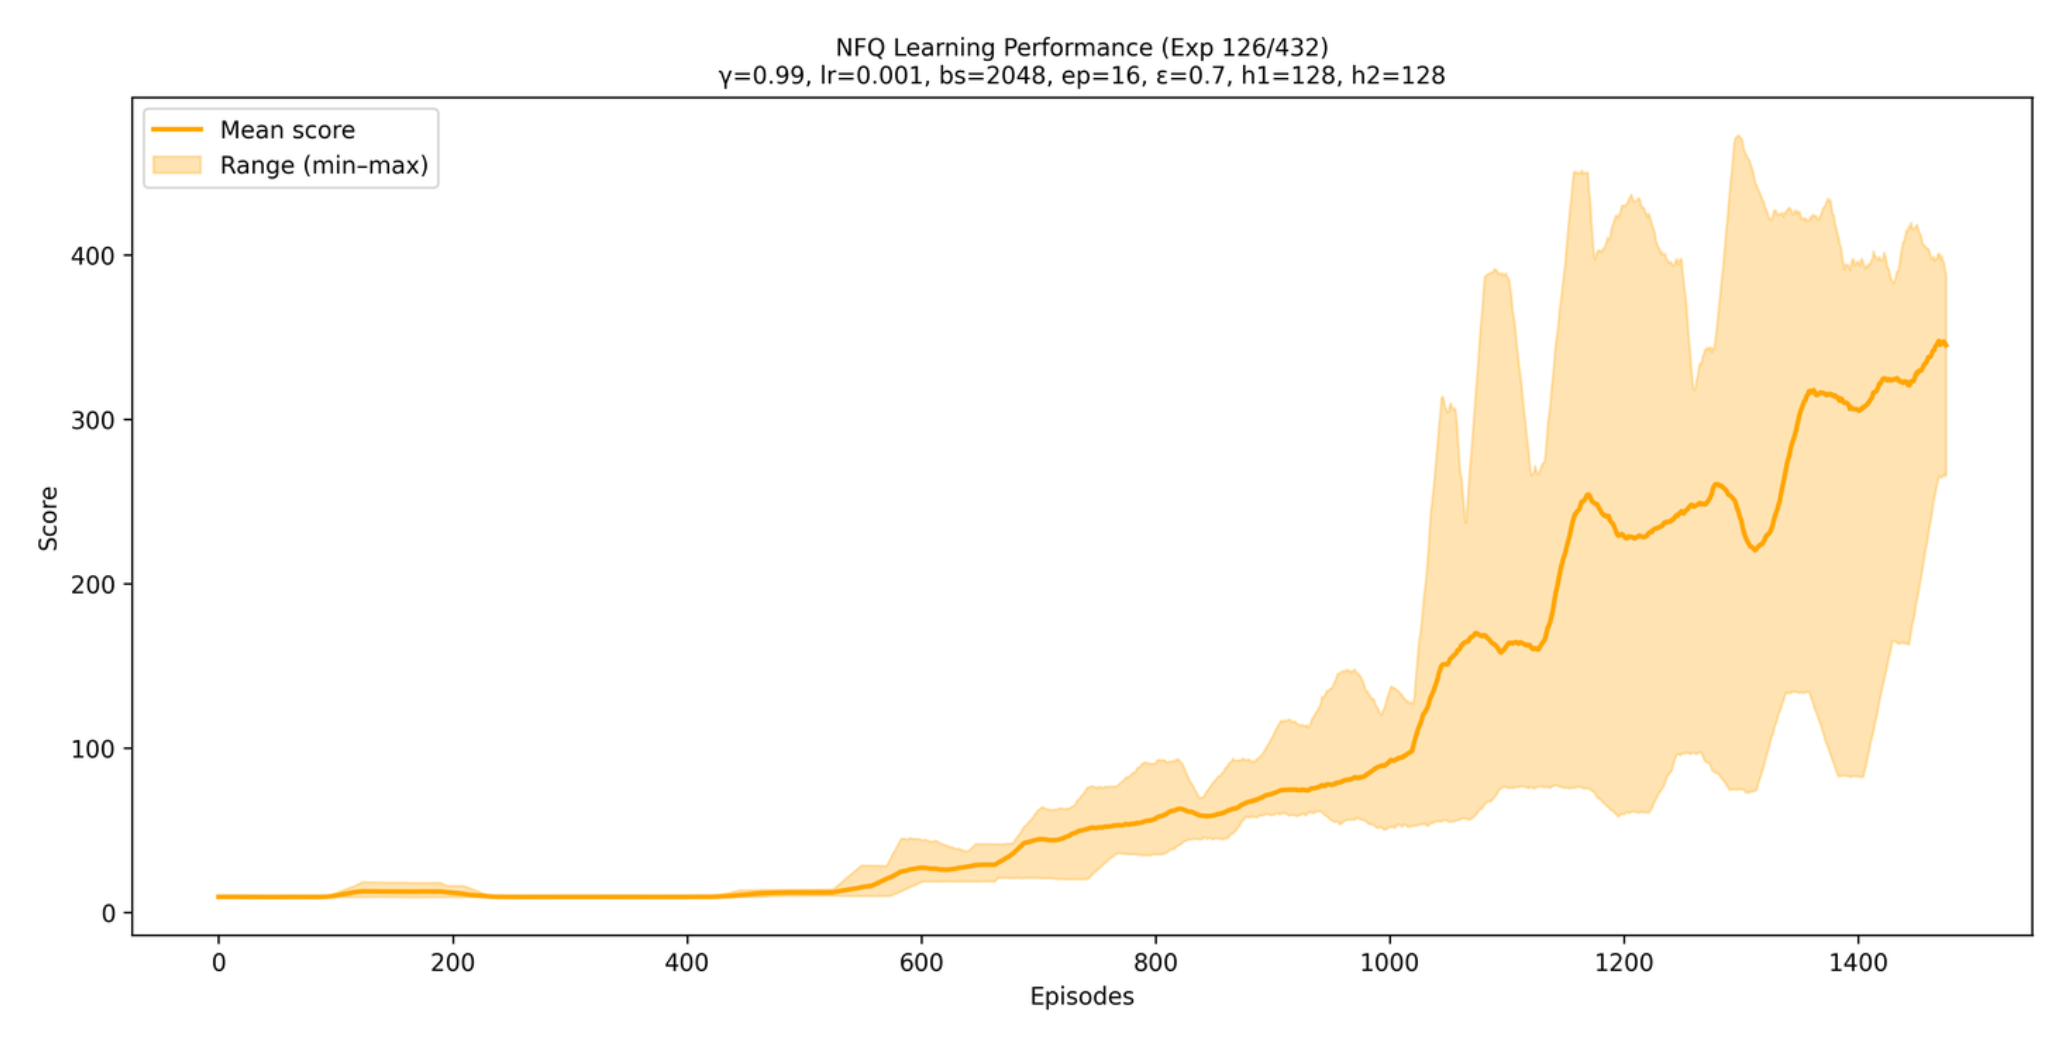

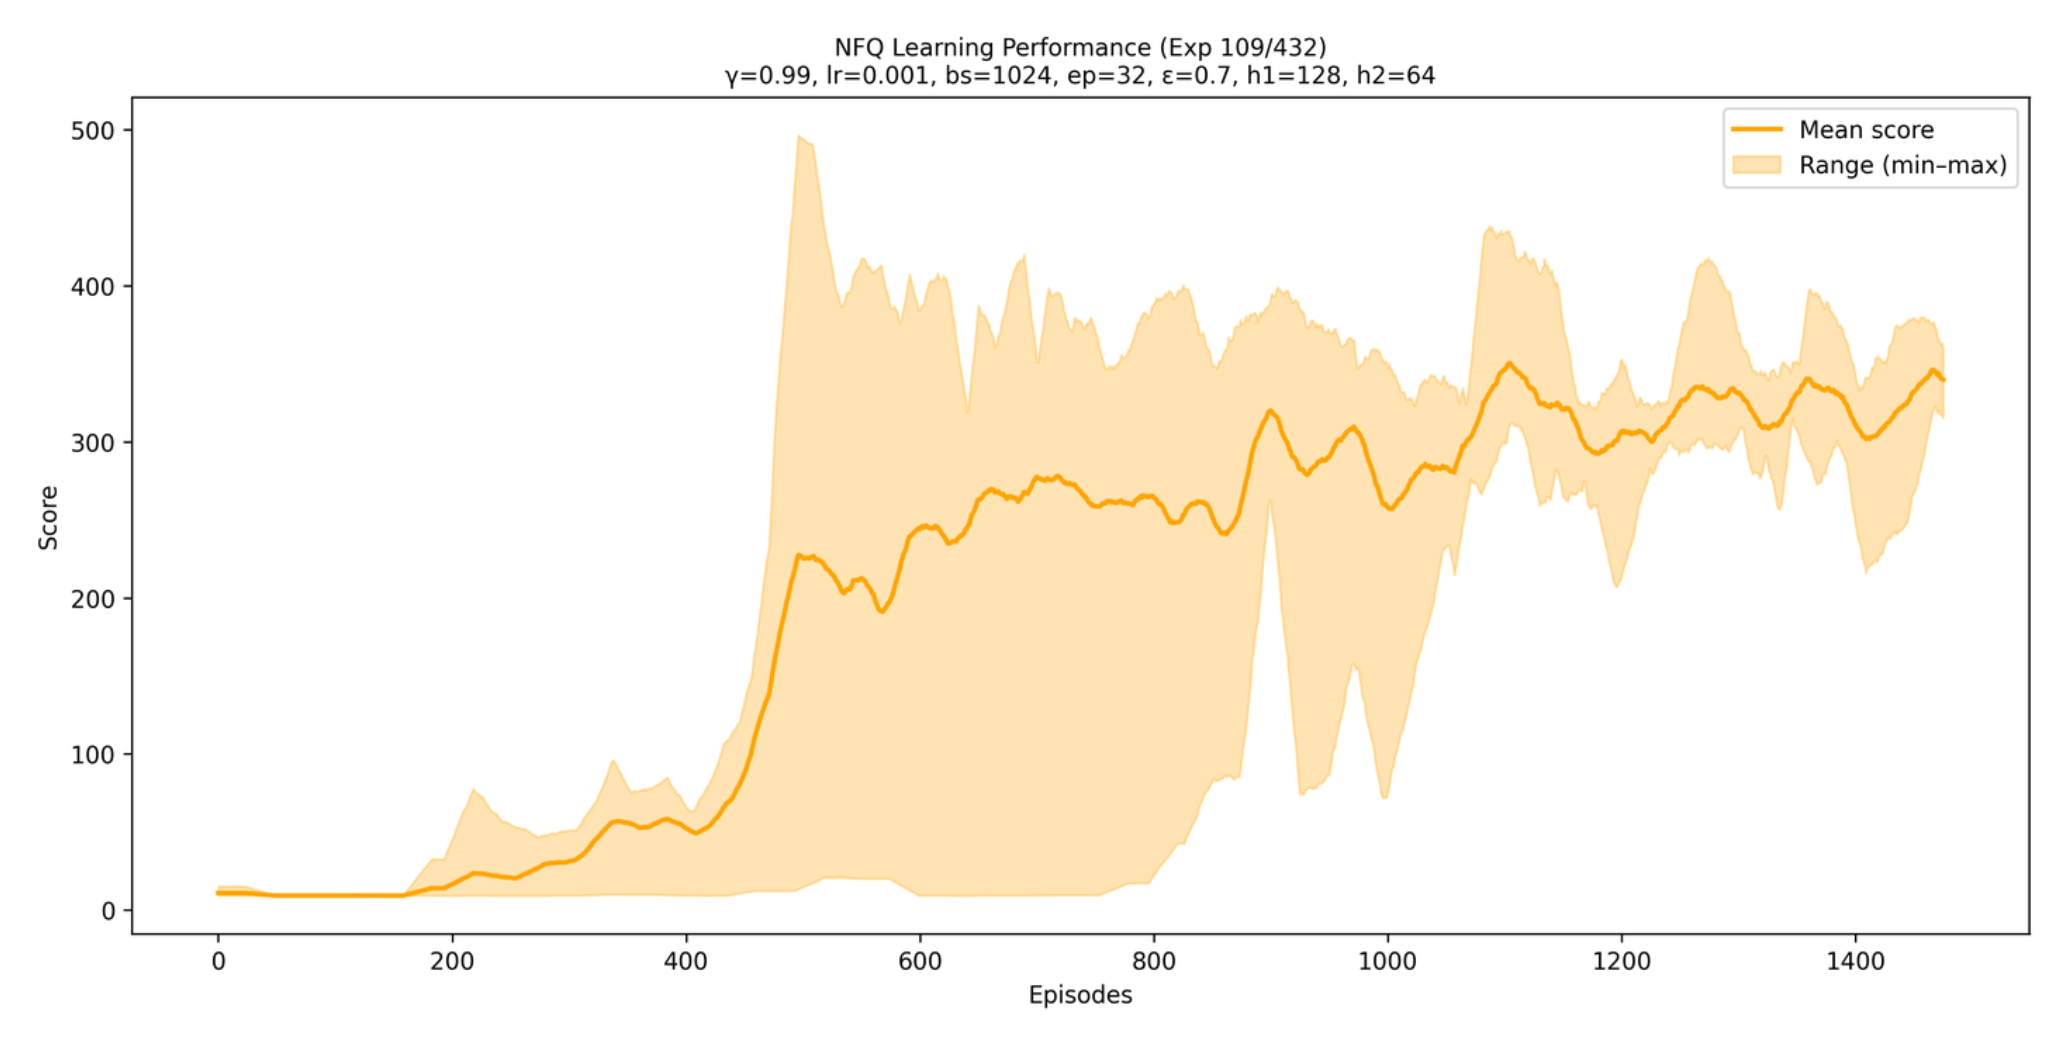

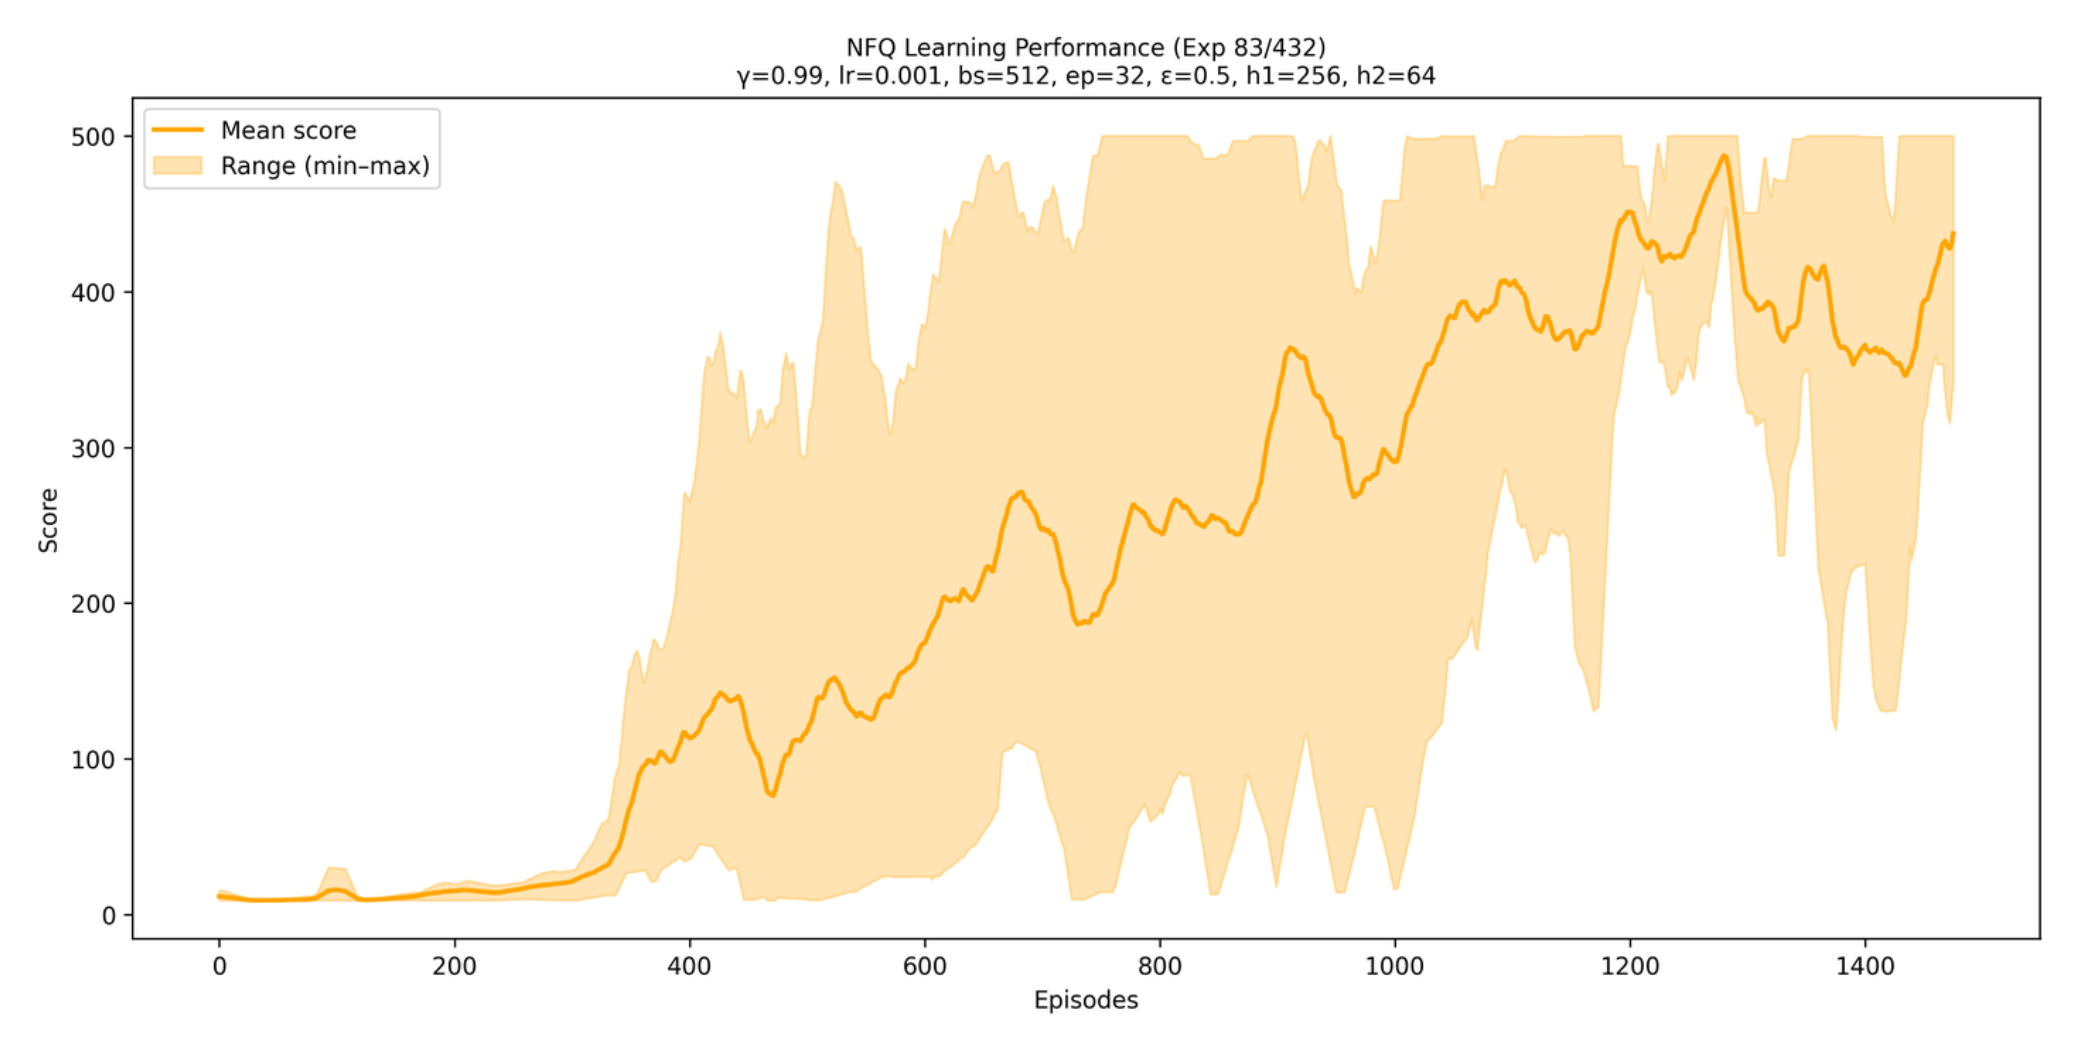

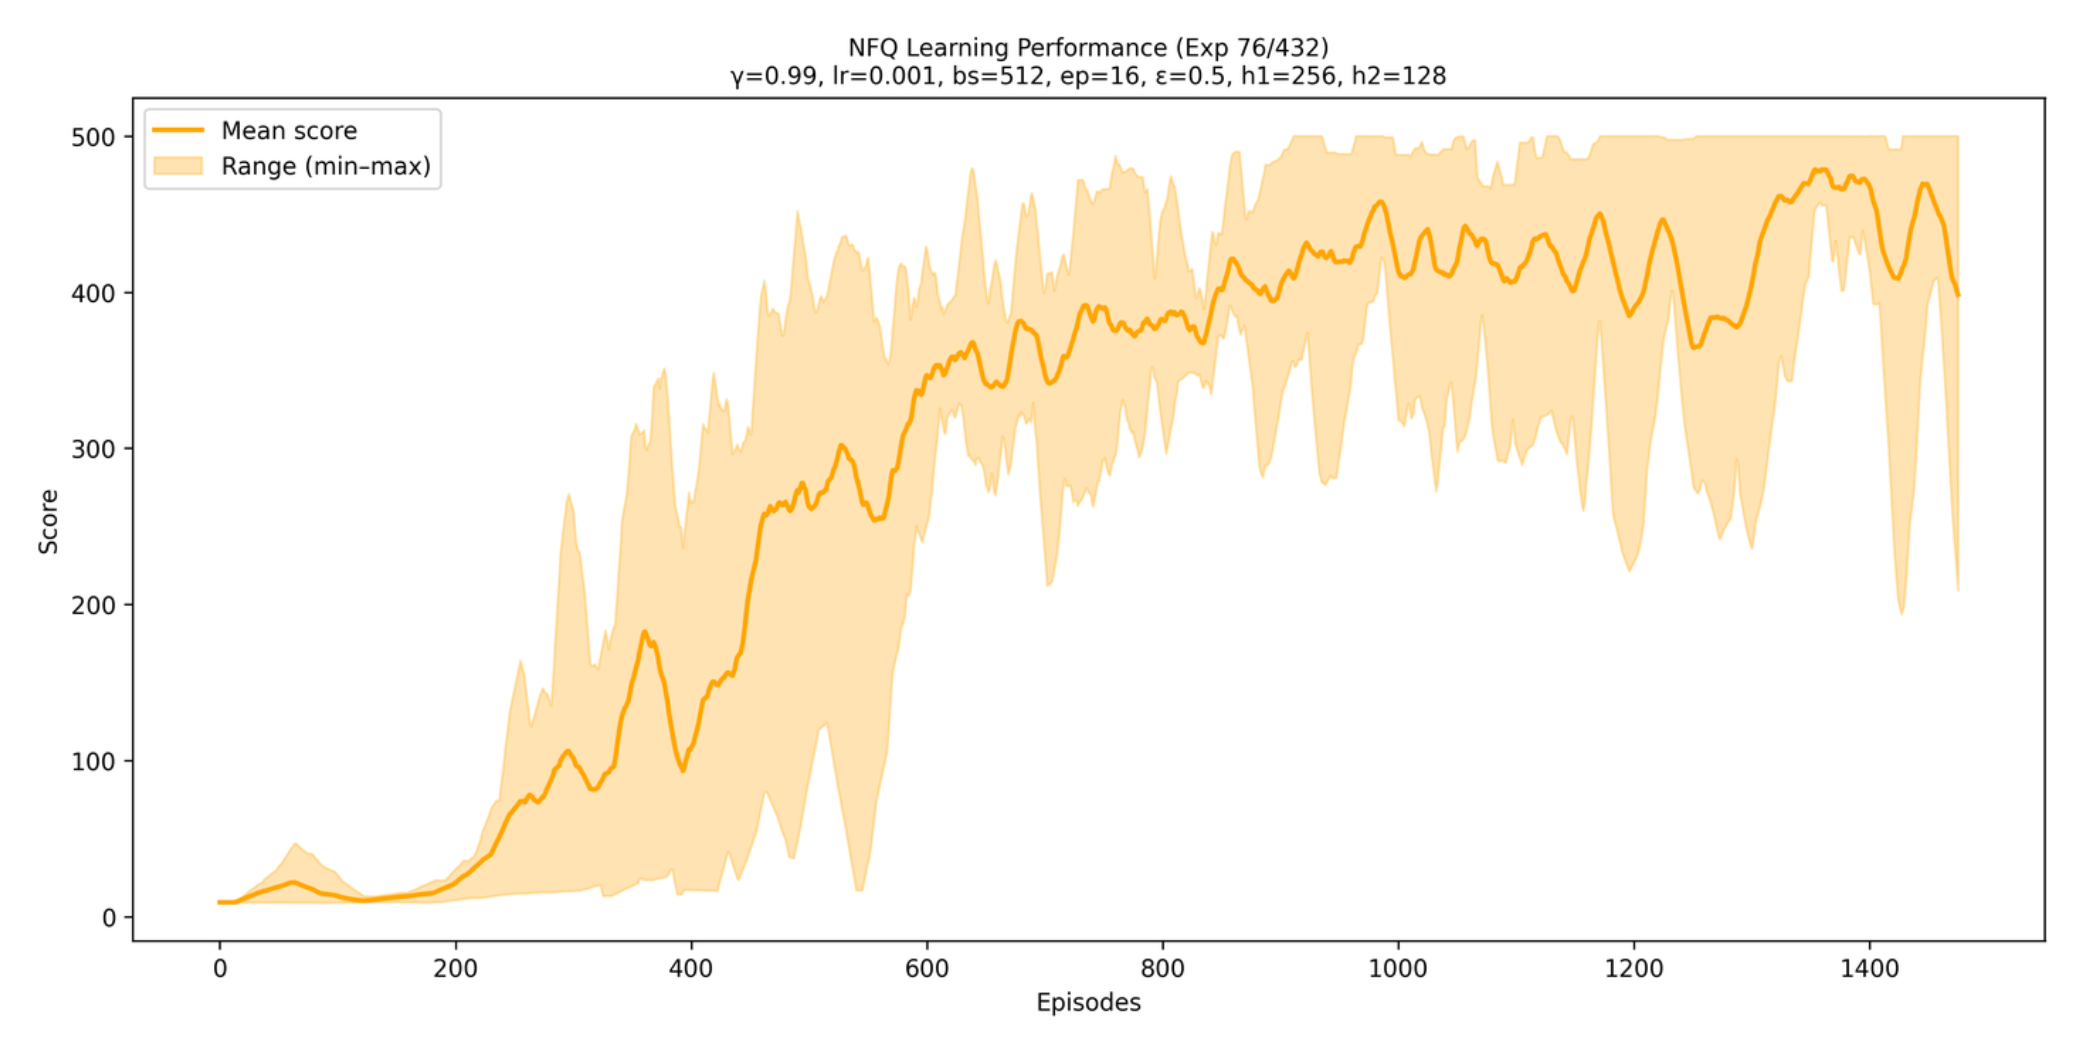

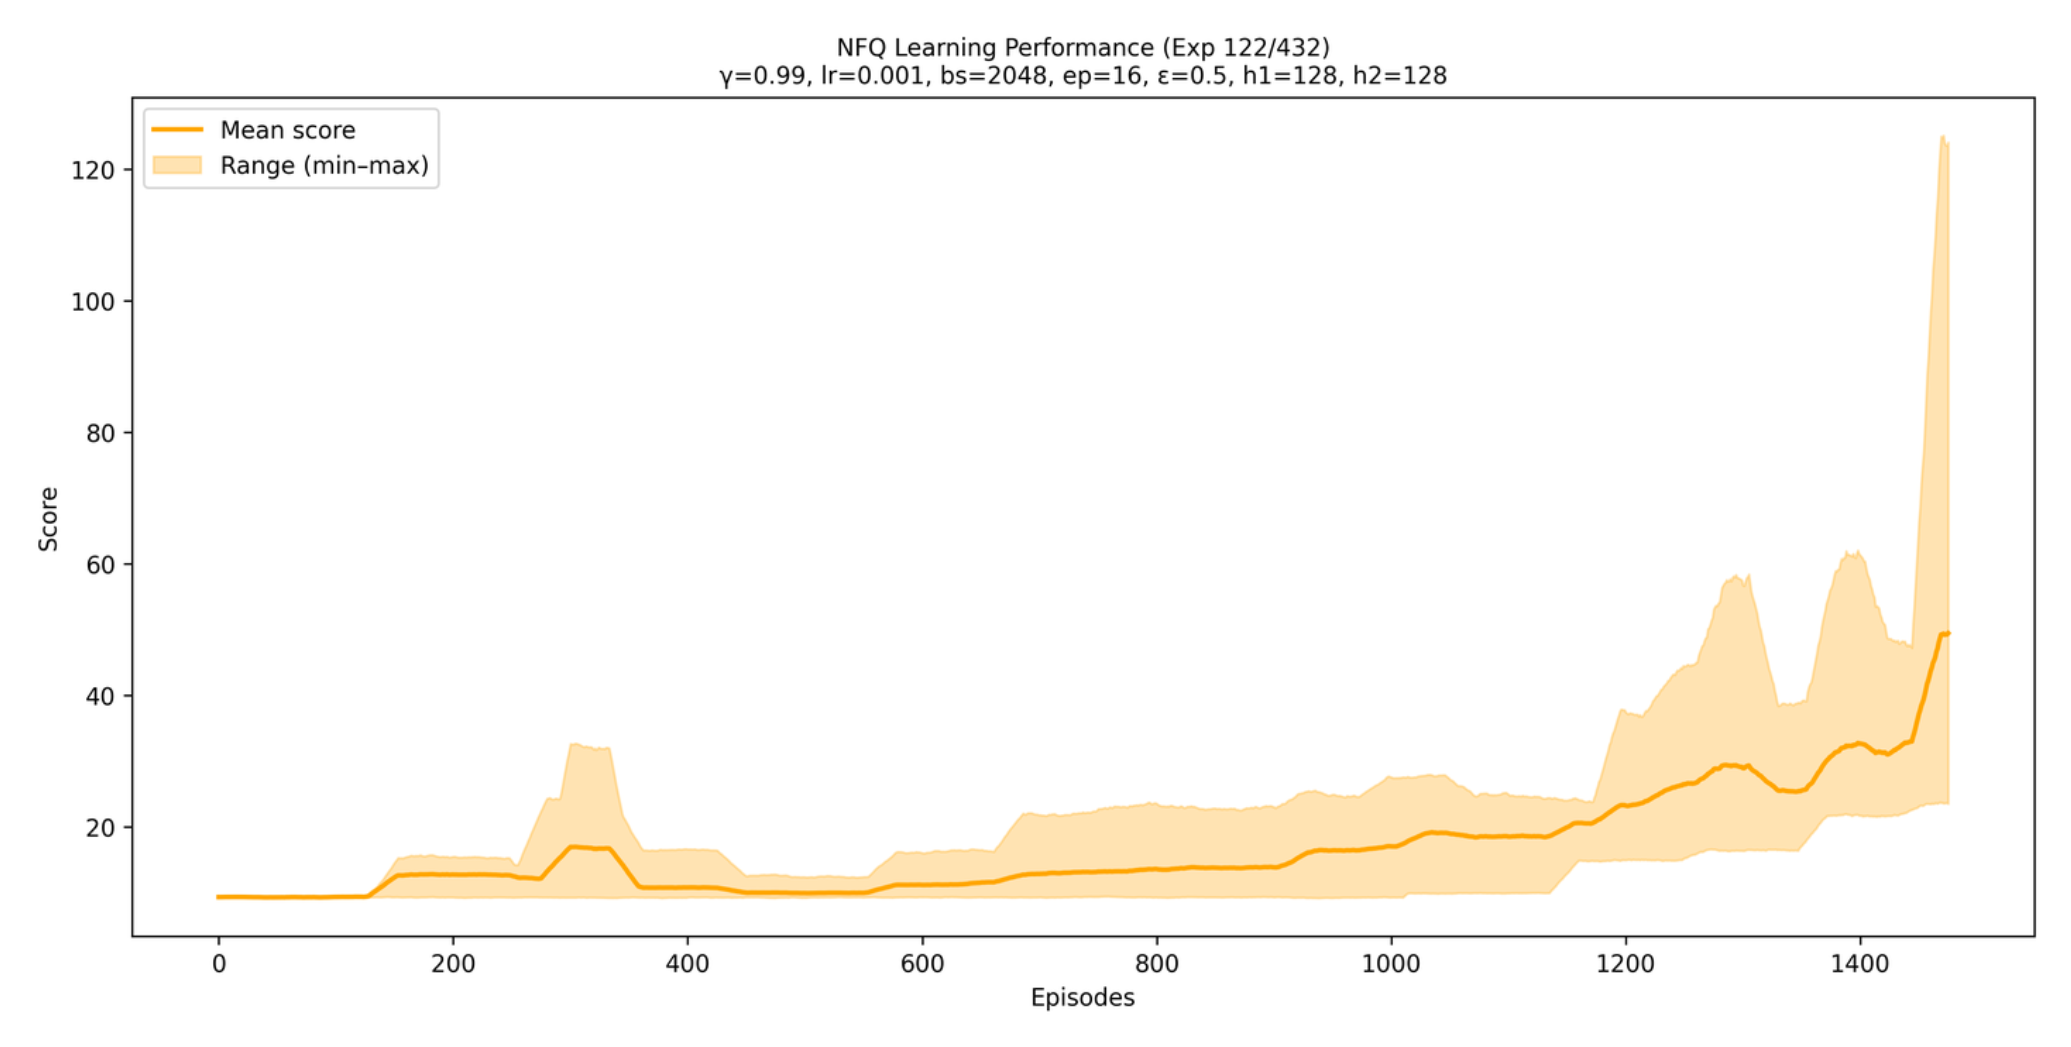

Across these NFQ experiments, several patterns emerge that reveal how the main hyperparameters influence learning stability and performance. The experiments with a **higher exploration rate consistently show faster and more reliable progress**. This suggests that a broader exploration phase allows the agent to discover more rewarding state–action pairs, avoiding premature convergence to suboptimal behaviors. When the exploration rate is reduced, learning becomes sluggish or erratic: the mean score either plateaus at low values or increases only very late in training. 

The batch size also plays an important role in shaping learning stability. **Larger batches produce smoother curves and more consistent improvement**, although the **first phase of learning tends to be slower**. As the number of samples decreases, the learning curve reacts faster but becomes increasingly noisy. The variability of the orange shaded region widens, indicating higher sensitivity to stochastic effects in the Q-target updates. In practice, this means that using very small batches accelerates feedback but destabilizes convergence, while large batches act as a regularizer, filtering out fluctuations and leading to steadier progress once the agent begins to improve.

The network architecture also influences the dynamics. The most balanced configurations, with **two hidden layers of 128 neurons each, achieve solid and consistent growth**. Reducing the second layer to 64 neurons slightly speeds up early learning without harming the final result. Larger architectures show wide oscillations in the score range. These networks may be **too expressive** for the amount of experience available, amplifying estimation noise and leading to overfitting of the Q-function to transient data patterns.

Overall, while some of these configurations eventually reach respectable scores, the collective picture suggests that **NFQ remains a rather brittle and inefficient learning method in this context**. Even in the best runs, progress is slow and unstable: the agent often spends hundreds of episodes with almost no improvement, and when performance finally increases, it tends to oscillate widely or collapse before stabilizing. The **strong dependence on hyperparameter tuning** (where small changes in exploration rate, batch size, or network width completely alter the learning dynamics) reveals that NFQ **lacks robustness**.

Moreover, the very large variance across seeds and experiments indicates that the algorithm **struggles to generalize** from replayed experience. It is highly sensitive to inaccuracies in the Q-targets. Errors can propagate through successive iterations and lead to instability or divergence. The fact that wider networks and smaller batches tend to explode in variance further confirms this weakness: NFQ does not regularize its function approximation effectively.

In short, despite occasional good results, the learning curves show that NFQ is not a particularly reliable or sample-efficient approach. These results highlight the algorithm’s historical and conceptual limitations: NFQ was an important step toward value-function approximation, but in practice it remains fragile and outdated compared with more recent reinforcement learning methods.